# Proyecto de Minería de Datos  
## Impacto de COVID-19 en la dinámica urbana de la Ciudad de México

**Objetivo del avance:** cargar, inspeccionar y preparar las fuentes de movilidad, seguridad, turismo, economía y contexto epidemiológico antes de realizar la integración final.

### Periodos de trabajo
- **Pre-COVID:** 2019
- **COVID:** 2020–2021
- **Recuperación:** 2022–2024

> Nota metodológica: para la comparación integrada se trabajará con periodicidad **mensual**, ya que es la mayor granularidad común natural entre las fuentes. Las fuentes con mayor granularidad se conservan también para análisis individuales.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RUTA = Path(".")


## 1. Archivos de entrada

Coloca los cinco CSV en la misma carpeta que este notebook o modifica las rutas siguientes.


In [46]:
ARCHIVOS = {
    "metro": RUTA / "Afluencia.csv",
    "seguridad": RUTA / "Seguridad.csv",
    "covid": RUTA / "COVID.csv",
    "economia": RUTA / "Economia.csv",
    "turismo": RUTA / "Turismo.csv",
}

for nombre, ruta in ARCHIVOS.items():
    print(f"{nombre:10s} -> {ruta} | existe: {ruta.exists()}")


metro      -> Afluencia.csv | existe: True
seguridad  -> Seguridad.csv | existe: True
covid      -> COVID.csv | existe: True
economia   -> Economia.csv | existe: True
turismo    -> Turismo.csv | existe: True


## 2. Carga de datos

Para **seguridad** se leen únicamente las columnas necesarias. Esto reduce considerablemente el consumo de memoria sin modificar el archivo original.


In [47]:
metro = pd.read_csv(ARCHIVOS["metro"], low_memory=False)

columnas_seguridad = [
    "anio_inicio",
    "mes_inicio",
    "fecha_inicio",
    "delito",
    "categoria_delito",
    "alcaldia_hecho",
]

seguridad = pd.read_csv(
    ARCHIVOS["seguridad"],
    usecols=columnas_seguridad,
    low_memory=False
)

covid = pd.read_csv(ARCHIVOS["covid"], low_memory=False)
economia = pd.read_csv(ARCHIVOS["economia"], low_memory=False)
turismo = pd.read_csv(ARCHIVOS["turismo"], low_memory=False)

print("Carga finalizada.")


Carga finalizada.


## 3. Inspección inicial

Esta sección se ejecuta **antes de limpiar** los datos para documentar sus características originales: dimensiones, columnas, tipos, valores faltantes y duplicados.


In [48]:
def inspeccionar(nombre, df):
    print("=" * 80)
    print(nombre.upper())
    print("=" * 80)
    print(f"Filas: {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]}")
    print("\nColumnas:")
    print(df.columns.tolist())
    print("\nTipos:")
    print(df.dtypes)
    print("\nValores faltantes:")
    print(df.isna().sum())
    print(f"\nDuplicados exactos: {df.duplicated().sum():,}")
    print("\nPrimeros registros:")
    display(df.head())

for nombre, df in {
    "Metro": metro,
    "Seguridad": seguridad,
    "COVID": covid,
    "Economía": economia,
    "Turismo": turismo,
}.items():
    inspeccionar(nombre, df)


METRO
Filas: 498,615
Columnas: 6

Columnas:
['fecha', 'anio', 'mes', 'linea', 'estacion', 'afluencia']

Tipos:
fecha        object
anio          int64
mes          object
linea        object
estacion     object
afluencia     int64
dtype: object

Valores faltantes:
fecha        0
anio         0
mes          0
linea        0
estacion     0
afluencia    0
dtype: int64

Duplicados exactos: 0

Primeros registros:


,fecha,anio,mes,linea,estacion,afluencia
0,2018-01-01,2018,Enero,Linea 1,PantitlÃ¡n,16979
1,2018-01-01,2018,Enero,Linea 1,Balbuena,3739
2,2018-01-01,2018,Enero,Linea 1,Isabel la CatÃ³lica,7718
3,2018-01-01,2018,Enero,Linea 1,Candelaria,7775
4,2018-01-01,2018,Enero,Linea 1,Merced,15175


SEGURIDAD
Filas: 1,495,008
Columnas: 6

Columnas:
['anio_inicio', 'mes_inicio', 'fecha_inicio', 'delito', 'categoria_delito', 'alcaldia_hecho']

Tipos:
anio_inicio          int64
mes_inicio          object
fecha_inicio        object
delito              object
categoria_delito    object
alcaldia_hecho      object
dtype: object

Valores faltantes:
anio_inicio             0
mes_inicio              0
fecha_inicio            3
delito                  0
categoria_delito        0
alcaldia_hecho      18692
dtype: int64

Duplicados exactos: 686,138

Primeros registros:


,anio_inicio,mes_inicio,fecha_inicio,delito,categoria_delito,alcaldia_hecho
0,2019,Enero,2019-01-01,POSESION DE VEHICULO ROBADO,DELITO DE BAJO IMPACTO,LA MAGDALENA CONTRERAS
1,2019,Enero,2019-01-01,ROBO A CASA HABITACION SIN VIOLENCIA,DELITO DE BAJO IMPACTO,BENITO JUAREZ
2,2019,Enero,2019-01-01,NEGACION DEL SERVICIO PUBLICO,DELITO DE BAJO IMPACTO,CUAUHTEMOC
3,2019,Enero,2019-01-01,ROBO DE VEHICULO DE SERVICIO PARTICULAR CON VI...,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,IZTAPALAPA
4,2019,Enero,2019-01-01,ROBO A PASAJERO / CONDUCTOR DE VEHICULO CON VI...,DELITO DE BAJO IMPACTO,IZTAPALAPA


COVID
Filas: 670
Columnas: 9

Columnas:
['fecha', 'anio', 'mes', 'hospitalizados_totales', 'hospitalizados_totales_cdmx', 'hospitalizados_totales_edomex', 'camas_intubados_totales', 'camas_intubados_cdmx', 'camas_intubados_edomex']

Tipos:
fecha                            object
anio                              int64
mes                              object
hospitalizados_totales            int64
hospitalizados_totales_cdmx       int64
hospitalizados_totales_edomex     int64
camas_intubados_totales           int64
camas_intubados_cdmx              int64
camas_intubados_edomex            int64
dtype: object

Valores faltantes:
fecha                            0
anio                             0
mes                              0
hospitalizados_totales           0
hospitalizados_totales_cdmx      0
hospitalizados_totales_edomex    0
camas_intubados_totales          0
camas_intubados_cdmx             0
camas_intubados_edomex           0
dtype: int64

Duplicados exactos: 1

Primeros regis

,fecha,anio,mes,hospitalizados_totales,hospitalizados_totales_cdmx,hospitalizados_totales_edomex,camas_intubados_totales,camas_intubados_cdmx,camas_intubados_edomex
0,2020-03-24,2020,marzo,50,50,0,39,39,0
1,2020-03-25,2020,marzo,105,105,0,33,33,0
2,2020-03-26,2020,marzo,128,128,0,42,42,0
3,2020-03-27,2020,marzo,175,175,0,60,60,0
4,2020-03-28,2020,marzo,257,257,0,78,78,0


ECONOMÍA
Filas: 68
Columnas: 2

Columnas:
['fecha', 'ciudad_de_mexico']

Tipos:
fecha               object
ciudad_de_mexico     int64
dtype: object

Valores faltantes:
fecha               0
ciudad_de_mexico    0
dtype: int64

Duplicados exactos: 0

Primeros registros:


,fecha,ciudad_de_mexico
0,2019-02-28,14884
1,2019-03-31,12341
2,2019-04-30,6319
3,2019-05-31,21197
4,2019-06-30,2886


TURISMO
Filas: 70
Columnas: 2

Columnas:
['fecha', 'ciudad_de_mexico']

Tipos:
fecha                object
ciudad_de_mexico    float64
dtype: object

Valores faltantes:
fecha               0
ciudad_de_mexico    0
dtype: int64

Duplicados exactos: 0

Primeros registros:


,fecha,ciudad_de_mexico
0,2018-10-31,73.17
1,2018-11-30,75.58
2,2018-12-31,65.45
3,2019-01-31,53.13
4,2019-02-28,69.30


## 4. Conversión y validación de fechas

El archivo de seguridad contiene fechas con más de un formato, por lo que se usa `format="mixed"` para interpretarlas correctamente.


In [49]:
metro["fecha"] = pd.to_datetime(metro["fecha"], errors="coerce")
seguridad["fecha_inicio"] = pd.to_datetime(
    seguridad["fecha_inicio"],
    format="mixed",
    errors="coerce"
)
covid["fecha"] = pd.to_datetime(covid["fecha"], errors="coerce")
economia["fecha"] = pd.to_datetime(economia["fecha"], errors="coerce")
turismo["fecha"] = pd.to_datetime(turismo["fecha"], errors="coerce")

rangos = pd.DataFrame({
    "dataset": ["Metro", "Seguridad", "COVID", "Economía", "Turismo"],
    "fecha_min": [
        metro["fecha"].min(),
        seguridad["fecha_inicio"].min(),
        covid["fecha"].min(),
        economia["fecha"].min(),
        turismo["fecha"].min(),
    ],
    "fecha_max": [
        metro["fecha"].max(),
        seguridad["fecha_inicio"].max(),
        covid["fecha"].max(),
        economia["fecha"].max(),
        turismo["fecha"].max(),
    ],
})

rangos

print("=== COBERTURA TEMPORAL ===")

print(
    "Metro:",
    metro["fecha"].min(),
    "→",
    metro["fecha"].max()
)

print(
    "Seguridad:",
    seguridad["fecha_inicio"].min(),
    "→",
    seguridad["fecha_inicio"].max()
)

print(
    "COVID:",
    covid["fecha"].min(),
    "→",
    covid["fecha"].max()
)

print(
    "Economía:",
    economia["fecha"].min(),
    "→",
    economia["fecha"].max()
)

print(
    "Turismo:",
    turismo["fecha"].min(),
    "→",
    turismo["fecha"].max()
)

print("\n=== DIMENSIONES ===")

datasets = {
    "Metro": metro,
    "Seguridad": seguridad,
    "COVID": covid,
    "Economía": economia,
    "Turismo": turismo
}

for nombre, df in datasets.items():
    print(f"{nombre:12s}: {df.shape[0]:,} filas x {df.shape[1]} columnas")

=== COBERTURA TEMPORAL ===
Metro: 2018-01-01 00:00:00 → 2024-12-31 00:00:00
Seguridad: 2016-01-01 00:00:00 → 2025-01-31 23:59:01
COVID: 2020-03-24 00:00:00 → 2022-02-09 00:00:00
Economía: 2019-02-28 00:00:00 → 2024-09-30 00:00:00
Turismo: 2018-10-31 00:00:00 → 2024-07-31 00:00:00

=== DIMENSIONES ===
Metro       : 498,615 filas x 6 columnas
Seguridad   : 1,495,008 filas x 6 columnas
COVID       : 670 filas x 9 columnas
Economía    : 68 filas x 2 columnas
Turismo     : 70 filas x 2 columnas


In [51]:
print("Valores únicos de 'anio_inicio' en el DataFrame original 'seguridad':")
display(seguridad['anio_inicio'].value_counts().sort_index())

Valores únicos de 'anio_inicio' en el DataFrame original 'seguridad':


,count
anio_inicio,
2016,25394
2017,24049
2018,28409
2019,250457
2020,204132
2021,230574
2022,239692
2023,242392
2024,232321


## 5. Problemas de calidad a documentar

Aquí se identifican problemas que posteriormente justificarán las decisiones de limpieza.


In [53]:
calidad = pd.DataFrame([
    {
        "dataset": "Metro",
        "filas": len(metro),
        "nulos_totales": int(metro.isna().sum().sum()),
        "duplicados_exactos": int(metro.duplicated().sum()),
    },
    {
        "dataset": "Seguridad",
        "filas": len(seguridad),
        "nulos_totales": int(seguridad.isna().sum().sum()),
        "duplicados_exactos": int(seguridad.duplicated().sum()),
    },
    {
        "dataset": "COVID",
        "filas": len(covid),
        "nulos_totales": int(covid.isna().sum().sum()),
        "duplicados_exactos": int(covid.duplicated().sum()),
    },
    {
        "dataset": "Economía",
        "filas": len(economia),
        "nulos_totales": int(economia.isna().sum().sum()),
        "duplicados_exactos": int(economia.duplicated().sum()),
    },
    {
        "dataset": "Turismo",
        "filas": len(turismo),
        "nulos_totales": int(turismo.isna().sum().sum()),
        "duplicados_exactos": int(turismo.duplicated().sum()),
    },
])

calidad


,dataset,filas,nulos_totales,duplicados_exactos
0,Metro,498615,0,0
1,Seguridad,1495008,18695,686179
2,COVID,670,0,1
3,Economía,68,0,0
4,Turismo,70,0,0


### 5.1 Revisión de codificación en Metro

En los datos del Metro pueden aparecer variantes como `Linea`, `Línea` o texto con caracteres mal decodificados.  
En esta etapa solo se detectan; la normalización se documentará en la sección de procesamiento.


In [54]:
print("Valores originales de línea:")
print(metro["linea"].value_counts(dropna=False).sort_index())

problemas_codificacion = metro[
    metro["linea"].astype(str).str.contains("Ã|Â", regex=True, na=False)
    | metro["estacion"].astype(str).str.contains("Ã|Â", regex=True, na=False)
]

print(f"Registros con posible problema de codificación: {len(problemas_codificacion):,}")
display(problemas_codificacion.head())


Valores originales de línea:
linea
Linea 1      33520
Linea 12     33520
Linea 2      40224
Linea 3      35196
Linea 4      16760
Linea 5      21788
Linea 6      18436
Linea 7      23464
Linea 8      31844
Linea 9      20112
Linea A      16760
Linea B      35196
LÃ­nea 1     17620
LÃ­nea 12    17620
LÃ­nea 2     21144
LÃ­nea 3     18501
LÃ­nea 4      8810
LÃ­nea 5     11453
LÃ­nea 6      9691
LÃ­nea 7     12334
LÃ­nea 8     16739
LÃ­nea 9     10572
LÃ­nea A      8810
LÃ­nea B     18501
Name: count, dtype: int64
Registros con posible problema de codificación: 276,223


,fecha,anio,mes,linea,estacion,afluencia
0,2018-01-01,2018,Enero,Linea 1,PantitlÃ¡n,16979
2,2018-01-01,2018,Enero,Linea 1,Isabel la CatÃ³lica,7718
5,2018-01-01,2018,Enero,Linea 2,Pino SuÃ¡rez,11418
11,2018-01-01,2018,Enero,Linea 3,Centro MÃ©dico,5184
12,2018-01-01,2018,Enero,Linea 3,EtiopÃ­a/Plaza de la Transparencia,8359


## 6. Filtrado temporal para el proyecto

Para seguridad se utiliza **`anio_inicio` / `fecha_inicio`**, no el año del hecho.  
Esto representa el momento en que la carpeta de investigación fue iniciada.

El análisis principal utiliza 2019–2024. La integración común exacta se ajustará posteriormente según la cobertura mensual de todas las fuentes.


In [55]:
seguridad_2019_2024 = seguridad[
    seguridad["anio_inicio"].between(2019, 2024)
].copy()

metro_2019_2024 = metro[
    metro["fecha"].dt.year.between(2019, 2024)
].copy()

print(f"Seguridad 2019–2024: {len(seguridad_2019_2024):,} registros")
print(f"Metro 2019–2024: {len(metro_2019_2024):,} registros")


Seguridad 2019–2024: 1,399,568 registros
Metro 2019–2024: 427,440 registros


## 7. Variable de periodo

Se agrega únicamente para facilitar las comparaciones estadísticas.  
No implica que todos los efectos de la pandemia hayan terminado exactamente en 2022.


In [56]:
def clasificar_periodo(anio):
    if anio == 2019:
        return "Pre-COVID"
    elif anio in (2020, 2021):
        return "COVID"
    elif 2022 <= anio <= 2024:
        return "Recuperación"
    return "Fuera del análisis"

# Ejemplo
pd.Series(range(2019, 2025)).to_frame("anio").assign(
    periodo=lambda x: x["anio"].map(clasificar_periodo)
)


,anio,periodo
0,2019,Pre-COVID
1,2020,COVID
2,2021,COVID
3,2022,Recuperación
4,2023,Recuperación
5,2024,Recuperación


## 8. Agregación mensual preliminar

Todavía no se realiza la limpieza definitiva. Esta sección sirve para validar que las fuentes pueden llevarse a una escala temporal común.


In [57]:
# Metro: suma mensual de entradas
metro_mensual = (
    metro_2019_2024
    .assign(mes_fecha=lambda x: x["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes_fecha", as_index=False)["afluencia"]
    .sum()
    .rename(columns={"afluencia": "afluencia_metro"})
)

# Seguridad: número de carpetas iniciadas por mes
seguridad_mensual = (
    seguridad_2019_2024
    .dropna(subset=["fecha_inicio"])
    .assign(mes_fecha=lambda x: x["fecha_inicio"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes_fecha", as_index=False)
    .size()
    .rename(columns={"size": "carpetas_fgJ"})
)

# Economía y turismo ya son mensuales
economia_mensual = economia.copy()
economia_mensual["mes_fecha"] = economia_mensual["fecha"].dt.to_period("M").dt.to_timestamp()
economia_mensual = economia_mensual[["mes_fecha", "ciudad_de_mexico"]].rename(
    columns={"ciudad_de_mexico": "empleos_formales"}
)

turismo_mensual = turismo.copy()
turismo_mensual["mes_fecha"] = turismo_mensual["fecha"].dt.to_period("M").dt.to_timestamp()
turismo_mensual = turismo_mensual[["mes_fecha", "ciudad_de_mexico"]].rename(
    columns={"ciudad_de_mexico": "ocupacion_hotelera"}
)

display(metro_mensual.head())
display(seguridad_mensual.head())
display(economia_mensual.head())
display(turismo_mensual.head())


,mes_fecha,afluencia_metro
0,2019-01-01,133040079
1,2019-02-01,124568306
2,2019-03-01,132417573
3,2019-04-01,121308154
4,2019-05-01,140358775


,mes_fecha,carpetas_fgJ
0,2019-01-01,21384
1,2019-02-01,20659
2,2019-03-01,22076
3,2019-04-01,20790
4,2019-05-01,22094


,mes_fecha,empleos_formales
0,2019-02-01,14884
1,2019-03-01,12341
2,2019-04-01,6319
3,2019-05-01,21197
4,2019-06-01,2886


,mes_fecha,ocupacion_hotelera
0,2018-10-01,73.17
1,2018-11-01,75.58
2,2018-12-01,65.45
3,2019-01-01,53.13
4,2019-02-01,69.30


## 9. Plan de contingencia: dataset > 1,000 registros

Si el proyecto final exige más de 1,000 observaciones, **no se inventarán datos diarios ni se repetirán artificialmente indicadores mensuales**.

La unidad de observación cambiará a:

> **estación–línea–mes**

Cada estación del Metro aporta una observación mensual. Los indicadores de seguridad, economía y turismo del mismo mes pueden incorporarse como **variables contextuales de ciudad**.

Con el periodo común aproximado de febrero de 2019 a julio de 2024 se esperan alrededor de **12,800 registros**, por lo que este diseño supera ampliamente una eventual exigencia de 1,000 observaciones.

Esta estructura permitiría aplicar clustering o modelos posteriores a nivel estación-mes.


In [58]:
# Comprobación del tamaño potencial del plan de contingencia.
# Esta celda NO construye todavía el dataset final.

def corregir_mojibake(valor):
    if pd.isna(valor):
        return valor
    texto = str(valor)
    if "Ã" in texto or "Â" in texto:
        try:
            return texto.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            return texto
    return texto

metro_contingencia = metro.copy()
metro_contingencia["linea_limpia"] = (
    metro_contingencia["linea"]
    .map(corregir_mojibake)
    .str.replace(r"^Linea\b", "Línea", regex=True)
)
metro_contingencia["estacion_limpia"] = metro_contingencia["estacion"].map(corregir_mojibake)

metro_contingencia = metro_contingencia[
    metro_contingencia["fecha"].between("2019-02-01", "2024-07-31")
].copy()

metro_estacion_mes = (
    metro_contingencia
    .assign(mes_fecha=lambda x: x["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby(
        ["mes_fecha", "linea_limpia", "estacion_limpia"],
        as_index=False
    )["afluencia"]
    .sum()
)

print(f"Registros estación–línea–mes: {len(metro_estacion_mes):,}")
print(f"Meses: {metro_estacion_mes['mes_fecha'].nunique()}")
print(f"Combinaciones estación-línea: {metro_estacion_mes[['linea_limpia','estacion_limpia']].drop_duplicates().shape[0]}")
display(metro_estacion_mes.head())


Registros estación–línea–mes: 12,869
Meses: 66
Combinaciones estación-línea: 197


,mes_fecha,linea_limpia,estacion_limpia,afluencia
0,2019-02-01,Línea 1,Balbuena,367338
1,2019-02-01,Línea 1,Balderas,638686
2,2019-02-01,Línea 1,Boulevard Puerto Aéreo,675875
3,2019-02-01,Línea 1,Candelaria,648318
4,2019-02-01,Línea 1,Chapultepec,1505029


# 10. Limpieza y preparación de los datos

En esta sección se realizan las transformaciones necesarias para corregir problemas
de calidad identificados durante la inspección inicial.

Las modificaciones se realizan sobre copias de los DataFrames originales para
conservar intactos los datos de entrada y poder comparar el estado previo y posterior
al procesamiento.

In [59]:
# Se crean copias para no modificar los DataFrames originales

metro_limpio = metro.copy()
seguridad_limpio = seguridad.copy()
covid_limpio = covid.copy()
economia_limpio = economia.copy()
turismo_limpio = turismo.copy()

print("Copias de trabajo creadas correctamente.")

Copias de trabajo creadas correctamente.


## 10.1 Limpieza del dataset de afluencia del Metro

Durante la inspección se detectaron problemas de codificación de caracteres en los
nombres de líneas y estaciones. Por ejemplo, algunos registros contienen textos como
`LÃ­nea` o `PantitlÃ¡n`.

También existen dos formas de escribir las líneas: `Linea` y `Línea`.
Estas variantes deben normalizarse para evitar que una misma línea sea considerada
como categorías diferentes.

In [60]:
def reparar_texto(valor):
    """
    Corrige cadenas con problemas comunes de codificación UTF-8/Latin-1
    y elimina espacios innecesarios.
    """
    if pd.isna(valor):
        return valor

    texto = str(valor).strip()

    # Reparación de mojibake: LÃ­nea -> Línea, PantitlÃ¡n -> Pantitlán, etc.
    if "Ã" in texto or "Â" in texto:
        try:
            texto = texto.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            pass

    # Elimina espacios múltiples
    texto = " ".join(texto.split())

    return texto


metro_limpio["linea"] = metro_limpio["linea"].apply(reparar_texto)
metro_limpio["estacion"] = metro_limpio["estacion"].apply(reparar_texto)

# Unificación del término "Linea" -> "Línea"
metro_limpio["linea"] = metro_limpio["linea"].str.replace(
    r"^Linea\b",
    "Línea",
    regex=True
)

print("Normalización de texto aplicada.")

Normalización de texto aplicada.


In [61]:
print("=== VALIDACIÓN DEL METRO DESPUÉS DE NORMALIZAR ===")

print("\nNúmero de líneas:")
print(metro_limpio["linea"].nunique())

print("\nLíneas encontradas:")
print(sorted(metro_limpio["linea"].dropna().unique()))

print("\nNúmero de estaciones distintas:")
print(metro_limpio["estacion"].nunique())

print("\nRegistros con posibles problemas de codificación restantes:")
problemas_restantes = metro_limpio[
    metro_limpio["linea"].astype(str).str.contains("Ã|Â", regex=True, na=False)
    |
    metro_limpio["estacion"].astype(str).str.contains("Ã|Â", regex=True, na=False)
]

print(len(problemas_restantes))

=== VALIDACIÓN DEL METRO DESPUÉS DE NORMALIZAR ===

Número de líneas:
12

Líneas encontradas:
['Línea 1', 'Línea 12', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7', 'Línea 8', 'Línea 9', 'Línea A', 'Línea B']

Número de estaciones distintas:
165

Registros con posibles problemas de codificación restantes:
0


In [62]:
import os

print("=== DIAGNÓSTICO DEL ARCHIVO DE SEGURIDAD ===")

print("Ruta utilizada:")
print(ARCHIVOS["seguridad"])

print("\n¿Existe el archivo?")
print(os.path.exists(ARCHIVOS["seguridad"]))

print("\nTamaño del archivo:")
print(
    round(os.path.getsize(ARCHIVOS["seguridad"]) / (1024**2), 2),
    "MB"
)

print("\nDimensiones del DataFrame actualmente cargado:")
print(seguridad.shape)

print("\nRegistros por anio_inicio:")
print(
    seguridad["anio_inicio"]
    .value_counts()
    .sort_index()
)

=== DIAGNÓSTICO DEL ARCHIVO DE SEGURIDAD ===
Ruta utilizada:
Seguridad.csv

¿Existe el archivo?
True

Tamaño del archivo:
393.78 MB

Dimensiones del DataFrame actualmente cargado:
(1495008, 6)

Registros por anio_inicio:
anio_inicio
2016     25394
2017     24049
2018     28409
2019    250457
2020    204132
2021    230574
2022    239692
2023    242392
2024    232321
2025     17588
Name: count, dtype: int64


## 10.2 Limpieza del dataset de seguridad

Para este proyecto se utiliza la fecha de inicio de la carpeta de investigación
(`fecha_inicio`) y no la fecha en que ocurrió el hecho.

Esto permite estudiar el comportamiento temporal de las carpetas registradas ante la
Fiscalía durante los periodos definidos en el proyecto.

Se conservan únicamente los registros correspondientes al periodo 2019-2024.

No se eliminan registros aparentemente duplicados basándose solamente en fecha,
delito, categoría y alcaldía, ya que dos carpetas de investigación distintas pueden
compartir esas características.

In [63]:
# Conversión de fecha
seguridad_limpio["fecha_inicio"] = pd.to_datetime(
    seguridad_limpio["fecha_inicio"],
    format="mixed",
    errors="coerce"
)

# Contabilizamos fechas no interpretables antes de eliminarlas
seguridad_sin_fecha = seguridad_limpio["fecha_inicio"].isna().sum()

# Eliminamos únicamente registros sin fecha válida
seguridad_limpio = seguridad_limpio.dropna(
    subset=["fecha_inicio"]
).copy()

# Periodo definitivo del proyecto para seguridad: 2019–2024
seguridad_limpio = seguridad_limpio[
    seguridad_limpio["fecha_inicio"].between(
        "2019-01-01",
        "2024-12-31"
    )
].copy()

# Normalización básica de campos categóricos
for columna in ["delito", "categoria_delito", "alcaldia_hecho"]:
    seguridad_limpio[columna] = (
        seguridad_limpio[columna]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print(f"Registros eliminados por fecha inválida: {seguridad_sin_fecha}")
print(f"Registros finales de seguridad: {len(seguridad_limpio):,}")

print(
    "Periodo:",
    seguridad_limpio["fecha_inicio"].min(),
    "→",
    seguridad_limpio["fecha_inicio"].max()
)

print("\nRegistros por año:")
print(
    seguridad_limpio["fecha_inicio"]
    .dt.year
    .value_counts()
    .sort_index()
)

Registros eliminados por fecha inválida: 3
Registros finales de seguridad: 1,399,160
Periodo: 2019-01-01 00:00:00 → 2024-12-30 23:52:16

Registros por año:
fecha_inicio
2019    250457
2020    204129
2021    230574
2022    239692
2023    242392
2024    231916
Name: count, dtype: int64


In [64]:
print("=== VALORES FALTANTES EN SEGURIDAD ===")

nulos_seguridad = pd.DataFrame({
    "nulos": seguridad_limpio.isna().sum(),
    "porcentaje": (
        seguridad_limpio.isna().mean() * 100
    ).round(2)
})

display(nulos_seguridad)

=== VALORES FALTANTES EN SEGURIDAD ===


,nulos,porcentaje
anio_inicio,0,0.00
mes_inicio,0,0.00
fecha_inicio,0,0.00
delito,0,0.00
categoria_delito,0,0.00
alcaldia_hecho,17505,1.25


### Observación sobre el archivo de origen

Durante la carga inicial del conjunto de datos de seguridad se detectaron saltos de línea
anómalos dentro del archivo CSV que interrumpían algunos registros e impedían la lectura
completa de la información.

El archivo fue corregido antes de continuar con el análisis y posteriormente se verificó
su integridad mediante el conteo de registros por año y la cobertura temporal.

Después de la corrección, el conjunto utilizado para el periodo 2019-2024 contiene
1,399,160 registros válidos. Se detectaron 3 registros con fechas no interpretables,
los cuales fueron excluidos debido a que no podían utilizarse en el análisis temporal.

La variable `alcaldia_hecho` presenta 17,505 valores faltantes (1.25 %). Estos registros
se conservan para los análisis globales de seguridad, ya que la ausencia de alcaldía no
impide contabilizar la carpeta de investigación. Únicamente serán excluidos si se
realizan análisis específicos por alcaldía.

## 10.3 Limpieza del dataset de hospitalizaciones por COVID-19

El dataset contiene información diaria sobre hospitalizaciones e intubaciones.
Durante la inspección inicial se detectó un registro duplicado exacto.

Debido a que se trata de una serie temporal diaria, los duplicados exactos sí pueden
eliminarse cuando contienen la misma fecha y los mismos valores en todas las variables.

In [65]:
# Conversión de fecha
covid_limpio["fecha"] = pd.to_datetime(
    covid_limpio["fecha"],
    errors="coerce"
)

duplicados_covid = covid_limpio.duplicated().sum()

print(f"Duplicados exactos antes de limpiar: {duplicados_covid}")

covid_limpio = (
    covid_limpio
    .drop_duplicates()
    .dropna(subset=["fecha"])
    .sort_values("fecha")
    .reset_index(drop=True)
)

print(f"Registros finales: {len(covid_limpio):,}")
print(
    "Periodo:",
    covid_limpio["fecha"].min(),
    "→",
    covid_limpio["fecha"].max()
)

Duplicados exactos antes de limpiar: 1
Registros finales: 669
Periodo: 2020-03-24 00:00:00 → 2022-02-09 00:00:00


## 10.4 Limpieza de los indicadores económicos y turísticos

Los datasets de economía y turismo ya presentan una estructura mensual simple.
Se convierten sus fechas al formato adecuado, se ordenan cronológicamente y se
renombra la variable principal para facilitar su interpretación e integración posterior.

In [66]:
# ECONOMÍA
economia_limpio["fecha"] = pd.to_datetime(
    economia_limpio["fecha"],
    errors="coerce"
)

economia_limpio = (
    economia_limpio
    .dropna(subset=["fecha"])
    .sort_values("fecha")
    .rename(columns={
        "ciudad_de_mexico": "empleos_formales"
    })
    .reset_index(drop=True)
)


# TURISMO
turismo_limpio["fecha"] = pd.to_datetime(
    turismo_limpio["fecha"],
    errors="coerce"
)

turismo_limpio = (
    turismo_limpio
    .dropna(subset=["fecha"])
    .sort_values("fecha")
    .rename(columns={
        "ciudad_de_mexico": "ocupacion_hotelera"
    })
    .reset_index(drop=True)
)

print("Economía:")
display(economia_limpio.head())

print("\nTurismo:")
display(turismo_limpio.head())

Economía:


,fecha,empleos_formales
0,2019-02-28,14884
1,2019-03-31,12341
2,2019-04-30,6319
3,2019-05-31,21197
4,2019-06-30,2886



Turismo:


,fecha,ocupacion_hotelera
0,2018-10-31,73.17
1,2018-11-30,75.58
2,2018-12-31,65.45
3,2019-01-31,53.13
4,2019-02-28,69.30


## 10.5 Creación de variables temporales

Para facilitar las comparaciones se generan variables de año, mes y periodo de
análisis.

Los periodos considerados son:

- 2019: Pre-COVID
- 2020-2021: COVID
- 2022-2024: Recuperación

La denominación "Recuperación" se utiliza como categoría operativa para el análisis
y no implica que todos los efectos asociados a la pandemia hayan finalizado en 2022.

In [67]:
def asignar_periodo(anio):
    if anio == 2019:
        return "Pre-COVID"
    elif anio in [2020, 2021]:
        return "COVID"
    elif anio in [2022, 2023, 2024]:
        return "Recuperación"
    else:
        return "Fuera del periodo"


# Metro
metro_limpio["anio_analisis"] = metro_limpio["fecha"].dt.year
metro_limpio["mes_num"] = metro_limpio["fecha"].dt.month
metro_limpio["periodo"] = metro_limpio["anio_analisis"].apply(asignar_periodo)

# Seguridad
seguridad_limpio["anio_analisis"] = seguridad_limpio["fecha_inicio"].dt.year
seguridad_limpio["mes_num"] = seguridad_limpio["fecha_inicio"].dt.month
seguridad_limpio["periodo"] = seguridad_limpio["anio_analisis"].apply(asignar_periodo)

# COVID
covid_limpio["anio_analisis"] = covid_limpio["fecha"].dt.year
covid_limpio["mes_num"] = covid_limpio["fecha"].dt.month
covid_limpio["periodo"] = covid_limpio["anio_analisis"].apply(asignar_periodo)

# Economía
economia_limpio["anio_analisis"] = economia_limpio["fecha"].dt.year
economia_limpio["mes_num"] = economia_limpio["fecha"].dt.month
economia_limpio["periodo"] = economia_limpio["anio_analisis"].apply(asignar_periodo)

# Turismo
turismo_limpio["anio_analisis"] = turismo_limpio["fecha"].dt.year
turismo_limpio["mes_num"] = turismo_limpio["fecha"].dt.month
turismo_limpio["periodo"] = turismo_limpio["anio_analisis"].apply(asignar_periodo)

print("Variables temporales creadas.")

Variables temporales creadas.


## 10.6 Validación final del procesamiento

In [68]:
print("=== RESUMEN DESPUÉS DE LA LIMPIEZA ===\n")

resumen_limpieza = pd.DataFrame({
    "Dataset": [
        "Metro",
        "Seguridad",
        "COVID",
        "Economía",
        "Turismo"
    ],

    "Registros": [
        len(metro_limpio),
        len(seguridad_limpio),
        len(covid_limpio),
        len(economia_limpio),
        len(turismo_limpio)
    ],

    "Nulos_totales": [
        metro_limpio.isna().sum().sum(),
        seguridad_limpio.isna().sum().sum(),
        covid_limpio.isna().sum().sum(),
        economia_limpio.isna().sum().sum(),
        turismo_limpio.isna().sum().sum()
    ]
})

display(resumen_limpieza)

=== RESUMEN DESPUÉS DE LA LIMPIEZA ===



,Dataset,Registros,Nulos_totales
0,Metro,498615,0
1,Seguridad,1399160,17505
2,COVID,669,0
3,Economía,68,0
4,Turismo,70,0


### Registros excluidos durante el procesamiento

Durante la etapa de limpieza se realizaron exclusiones únicamente cuando el registro
no podía utilizarse correctamente en el análisis:

- **Seguridad:** se excluyeron 3 registros cuya fecha de inicio no pudo interpretarse.
- **COVID-19:** se eliminó 1 registro duplicado exacto.
- **Metro:** no se eliminaron registros; únicamente se normalizaron problemas de
  codificación y escritura en nombres de líneas y estaciones.
- **Economía:** no se eliminaron registros.
- **Turismo:** no se eliminaron registros.

Los 17,505 valores faltantes de `alcaldia_hecho` en el dataset de seguridad se
conservaron, debido a que estos registros continúan siendo válidos para el análisis
global de carpetas de investigación. Solo deberán excluirse en análisis específicos
que requieran conocer la alcaldía.

# 11. Análisis estadístico

Para realizar una comparación entre los diferentes ámbitos, las fuentes se homologan
a una periodicidad mensual.

La transformación utilizada para cada indicador es:

- **Movilidad:** suma mensual de la afluencia registrada en todas las estaciones del Metro.
- **Seguridad:** número mensual de carpetas de investigación iniciadas.
- **Economía:** creación mensual de empleos formales reportada por el IMSS.
- **Turismo:** porcentaje mensual de ocupación hotelera.
- **COVID-19:** promedio y máximo mensual de personas hospitalizadas en la Ciudad de México.

La información epidemiológica se utiliza principalmente como variable de contexto,
ya que únicamente se encuentra disponible durante el periodo de la pandemia.

In [69]:
# =============================
# METRO
# =============================

metro_mensual = (
    metro_limpio
    .assign(
        fecha_mes=metro_limpio["fecha"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("fecha_mes", as_index=False)["afluencia"]
    .sum()
    .rename(columns={
        "afluencia": "afluencia_metro"
    })
)


# =============================
# SEGURIDAD
# =============================

seguridad_mensual = (
    seguridad_limpio
    .assign(
        fecha_mes=seguridad_limpio["fecha_inicio"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("fecha_mes", as_index=False)
    .size()
    .rename(columns={
        "size": "carpetas_fgJ"
    })
)


# =============================
# ECONOMÍA
# =============================

economia_mensual = economia_limpio.copy()

economia_mensual["fecha_mes"] = (
    economia_mensual["fecha"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

economia_mensual = economia_mensual[
    ["fecha_mes", "empleos_formales"]
].copy()


# =============================
# TURISMO
# =============================

turismo_mensual = turismo_limpio.copy()

turismo_mensual["fecha_mes"] = (
    turismo_mensual["fecha"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

turismo_mensual = turismo_mensual[
    ["fecha_mes", "ocupacion_hotelera"]
].copy()


# =============================
# COVID
# =============================

covid_limpio["fecha_mes"] = (
    covid_limpio["fecha"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

covid_mensual = (
    covid_limpio
    .groupby("fecha_mes", as_index=False)
    .agg(
        hospitalizados_promedio=(
            "hospitalizados_totales_cdmx",
            "mean"
        ),
        hospitalizados_maximo=(
            "hospitalizados_totales_cdmx",
            "max"
        )
    )
)

print("Series mensuales generadas correctamente.")

Series mensuales generadas correctamente.


In [70]:
def resumen_serie(nombre, df):
    print(f"\n=== {nombre.upper()} ===")
    print(f"Meses disponibles: {len(df)}")
    print(
        "Periodo:",
        df["fecha_mes"].min(),
        "→",
        df["fecha_mes"].max()
    )
    print("Duplicados de mes:", df["fecha_mes"].duplicated().sum())
    display(df.head())


resumen_serie("Metro", metro_mensual)
resumen_serie("Seguridad", seguridad_mensual)
resumen_serie("Economía", economia_mensual)
resumen_serie("Turismo", turismo_mensual)
resumen_serie("COVID", covid_mensual)


=== METRO ===
Meses disponibles: 84
Periodo: 2018-01-01 00:00:00 → 2024-12-01 00:00:00
Duplicados de mes: 0


,fecha_mes,afluencia_metro
0,2018-01-01,133567812
1,2018-02-01,129068104
2,2018-03-01,135831073
3,2018-04-01,137380658
4,2018-05-01,140608299



=== SEGURIDAD ===
Meses disponibles: 72
Periodo: 2019-01-01 00:00:00 → 2024-12-01 00:00:00
Duplicados de mes: 0


,fecha_mes,carpetas_fgJ
0,2019-01-01,21384
1,2019-02-01,20659
2,2019-03-01,22076
3,2019-04-01,20790
4,2019-05-01,22094



=== ECONOMÍA ===
Meses disponibles: 68
Periodo: 2019-02-01 00:00:00 → 2024-09-01 00:00:00
Duplicados de mes: 0


,fecha_mes,empleos_formales
0,2019-02-01,14884
1,2019-03-01,12341
2,2019-04-01,6319
3,2019-05-01,21197
4,2019-06-01,2886



=== TURISMO ===
Meses disponibles: 70
Periodo: 2018-10-01 00:00:00 → 2024-07-01 00:00:00
Duplicados de mes: 0


,fecha_mes,ocupacion_hotelera
0,2018-10-01,73.17
1,2018-11-01,75.58
2,2018-12-01,65.45
3,2019-01-01,53.13
4,2019-02-01,69.30



=== COVID ===
Meses disponibles: 24
Periodo: 2020-03-01 00:00:00 → 2022-02-01 00:00:00
Duplicados de mes: 0


,fecha_mes,hospitalizados_promedio,hospitalizados_maximo
0,2020-03-01,198.38,313
1,2020-04-01,"1,410.20",2900
2,2020-05-01,"4,011.65",4573
3,2020-06-01,"4,215.17",4491
4,2020-07-01,"3,471.06",3750


In [71]:
def detectar_meses_faltantes(nombre, df):
    inicio = df["fecha_mes"].min()
    fin = df["fecha_mes"].max()

    meses_esperados = pd.date_range(
        inicio,
        fin,
        freq="MS"
    )

    meses_presentes = pd.DatetimeIndex(
        df["fecha_mes"].unique()
    )

    faltantes = meses_esperados.difference(
        meses_presentes
    )

    print(f"\n{nombre}")
    print(f"Meses faltantes: {len(faltantes)}")

    if len(faltantes) > 0:
        print(faltantes)


detectar_meses_faltantes("Metro", metro_mensual)
detectar_meses_faltantes("Seguridad", seguridad_mensual)
detectar_meses_faltantes("Economía", economia_mensual)
detectar_meses_faltantes("Turismo", turismo_mensual)
detectar_meses_faltantes("COVID", covid_mensual)


Metro
Meses faltantes: 0

Seguridad
Meses faltantes: 0

Economía
Meses faltantes: 0

Turismo
Meses faltantes: 0

COVID
Meses faltantes: 0


## 11.4 Definición del periodo común de análisis

Aunque los conjuntos de datos presentan diferentes rangos temporales, se identificó
un intervalo común entre los principales indicadores de movilidad, seguridad,
economía y turismo.

El periodo común comprende de **febrero de 2019 a julio de 2024**, equivalente a
66 meses consecutivos.

Para facilitar la comparación se establecen tres categorías temporales:

- **Pre-COVID:** febrero a diciembre de 2019.
- **COVID:** enero de 2020 a diciembre de 2021.
- **Recuperación:** enero de 2022 a julio de 2024.

Los datos epidemiológicos de COVID-19 se utilizan como información contextual y no
determinan la extensión del periodo común, ya que su cobertura comprende únicamente
de marzo de 2020 a febrero de 2022.

In [72]:
inicio_comun = pd.Timestamp("2019-02-01")
fin_comun = pd.Timestamp("2024-07-01")


def filtrar_periodo_comun(df):
    return df[
        df["fecha_mes"].between(
            inicio_comun,
            fin_comun
        )
    ].copy()


metro_comun = filtrar_periodo_comun(metro_mensual)
seguridad_comun = filtrar_periodo_comun(seguridad_mensual)
economia_comun = filtrar_periodo_comun(economia_mensual)
turismo_comun = filtrar_periodo_comun(turismo_mensual)


print("Meses en periodo común:")
print("Metro:", len(metro_comun))
print("Seguridad:", len(seguridad_comun))
print("Economía:", len(economia_comun))
print("Turismo:", len(turismo_comun))

Meses en periodo común:
Metro: 66
Seguridad: 66
Economía: 66
Turismo: 66


In [73]:
def periodo_mensual(fecha):
    if fecha < pd.Timestamp("2020-01-01"):
        return "Pre-COVID"
    elif fecha < pd.Timestamp("2022-01-01"):
        return "COVID"
    else:
        return "Recuperación"


for df in [
    metro_comun,
    seguridad_comun,
    economia_comun,
    turismo_comun
]:
    df["periodo"] = df["fecha_mes"].apply(periodo_mensual)


print("Distribución de meses:")
print(
    metro_comun["periodo"]
    .value_counts()
)

Distribución de meses:
periodo
Recuperación    31
COVID           24
Pre-COVID       11
Name: count, dtype: int64


## 11.5 Estadística descriptiva por periodo

Se calcularon medidas descriptivas para cada indicador durante los tres periodos
definidos: Pre-COVID, COVID y Recuperación.

Las medidas utilizadas son:

- Número de meses observados.
- Media.
- Mediana.
- Desviación estándar.
- Valor mínimo.
- Primer cuartil (Q1).
- Tercer cuartil (Q3).
- Valor máximo.

Estas medidas permiten comparar el nivel promedio de cada indicador y su variabilidad
entre los distintos periodos.

In [74]:
def estadisticas_por_periodo(df, columna, nombre_indicador):
    resumen = (
        df.groupby("periodo")[columna]
        .agg(
            meses="count",
            media="mean",
            mediana="median",
            desviacion_std="std",
            minimo="min",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            maximo="max"
        )
        .reset_index()
    )

    resumen.insert(0, "indicador", nombre_indicador)

    orden = ["Pre-COVID", "COVID", "Recuperación"]

    resumen["periodo"] = pd.Categorical(
        resumen["periodo"],
        categories=orden,
        ordered=True
    )

    return resumen.sort_values("periodo").reset_index(drop=True)

In [75]:
estadisticas_metro = estadisticas_por_periodo(
    metro_comun,
    "afluencia_metro",
    "Afluencia del Metro"
)

estadisticas_seguridad = estadisticas_por_periodo(
    seguridad_comun,
    "carpetas_fgJ",
    "Carpetas de investigación"
)

estadisticas_economia = estadisticas_por_periodo(
    economia_comun,
    "empleos_formales",
    "Empleos formales"
)

estadisticas_turismo = estadisticas_por_periodo(
    turismo_comun,
    "ocupacion_hotelera",
    "Ocupación hotelera"
)

print("=== METRO ===")
display(estadisticas_metro)

print("\n=== SEGURIDAD ===")
display(estadisticas_seguridad)

print("\n=== ECONOMÍA ===")
display(estadisticas_economia)

print("\n=== TURISMO ===")
display(estadisticas_turismo)

=== METRO ===


,indicador,periodo,meses,media,mediana,desviacion_std,minimo,q1,q3,maximo
0,Afluencia del Metro,Pre-COVID,11,"132,873,745.45","131,005,128.00","6,889,735.45",121308154,"129,600,869.00","139,729,113.50",142472177
1,Afluencia del Metro,COVID,24,"70,355,162.12","67,091,855.50","23,902,208.85",35899769,"61,622,149.50","75,684,837.00",130708973
2,Afluencia del Metro,Recuperación,31,"90,466,576.35","90,759,617.00","6,886,795.75",70563670,"88,371,106.00","95,276,695.50",101016462



=== SEGURIDAD ===


,indicador,periodo,meses,media,mediana,desviacion_std,minimo,q1,q3,maximo
0,Carpetas de investigación,Pre-COVID,11,"20,824.82","20,790.00",894.82,19044,"20,607.00","21,257.00",22094
1,Carpetas de investigación,COVID,24,"18,112.62","19,328.50","2,658.91",11372,"16,864.25","19,852.75",21200
2,Carpetas de investigación,Recuperación,31,"20,023.23","20,246.00","1,254.32",16962,"19,304.50","20,869.50",22741



=== ECONOMÍA ===


,indicador,periodo,meses,media,mediana,desviacion_std,minimo,q1,q3,maximo
0,Empleos formales,Pre-COVID,11,"6,595.36","12,341.00","27,184.57",-70765,"4,900.00","18,040.50",32396
1,Empleos formales,COVID,24,"-6,560.67","-3,133.50","34,142.70",-105804,"-15,819.50","20,449.25",36935
2,Empleos formales,Recuperación,31,"6,629.03","11,338.00","19,475.08",-51214,802.50,"19,070.50",29873



=== TURISMO ===


,indicador,periodo,meses,media,mediana,desviacion_std,minimo,q1,q3,maximo
0,Ocupación hotelera,Pre-COVID,11,69.04,68.25,4.52,62.11,66.84,69.69,78.54
1,Ocupación hotelera,COVID,24,27.77,23.35,18.27,1.55,15.55,38.14,69.87
2,Ocupación hotelera,Recuperación,31,60.87,62.38,7.78,36.48,56.49,64.13,77.60


## 11.6 Cambios respecto al periodo Pre-COVID

Además de las medidas descriptivas, se calculó el cambio de la media de cada indicador
durante COVID y Recuperación respecto al periodo Pre-COVID.

La variación porcentual se calcula mediante:

$$
\text{Variación}(\%) =
\frac{\text{Media}_{\text{periodo}}-\text{Media}_{\text{Pre-COVID}}}
{\text{Media}_{\text{Pre-COVID}}}
\times 100
$$

En el indicador de empleos formales, los valores negativos representan una pérdida
neta de puestos registrados durante el mes, por lo que su variación porcentual debe
interpretarse con precaución y junto con el cambio absoluto.

In [76]:
def calcular_variaciones(resumen):
    resultado = resumen[
        ["indicador", "periodo", "media"]
    ].copy()

    media_pre = resultado.loc[
        resultado["periodo"] == "Pre-COVID",
        "media"
    ].iloc[0]

    resultado["cambio_absoluto_vs_pre"] = (
        resultado["media"] - media_pre
    )

    if media_pre != 0:
        resultado["variacion_pct_vs_pre"] = (
            resultado["cambio_absoluto_vs_pre"]
            / media_pre
            * 100
        )
    else:
        resultado["variacion_pct_vs_pre"] = np.nan

    return resultado


variaciones = pd.concat([
    calcular_variaciones(estadisticas_metro),
    calcular_variaciones(estadisticas_seguridad),
    calcular_variaciones(estadisticas_economia),
    calcular_variaciones(estadisticas_turismo)
], ignore_index=True)

variaciones[
    ["media", "cambio_absoluto_vs_pre", "variacion_pct_vs_pre"]
] = variaciones[
    ["media", "cambio_absoluto_vs_pre", "variacion_pct_vs_pre"]
].round(2)

display(variaciones)

,indicador,periodo,media,cambio_absoluto_vs_pre,variacion_pct_vs_pre
0,Afluencia del Metro,Pre-COVID,"132,873,745.45",0.00,0.00
1,Afluencia del Metro,COVID,"70,355,162.12","-62,518,583.33",-47.05
2,Afluencia del Metro,Recuperación,"90,466,576.35","-42,407,169.10",-31.92
3,Carpetas de investigación,Pre-COVID,"20,824.82",0.00,0.00
4,Carpetas de investigación,COVID,"18,112.62","-2,712.19",-13.02
5,Carpetas de investigación,Recuperación,"20,023.23",-801.59,-3.85
6,Empleos formales,Pre-COVID,"6,595.36",0.00,0.00
7,Empleos formales,COVID,"-6,560.67","-13,156.03",-199.47
8,Empleos formales,Recuperación,"6,629.03",33.67,0.51
9,Ocupación hotelera,Pre-COVID,69.04,0.00,0.00


In [77]:
tabla_comparativa = variaciones.pivot(
    index="indicador",
    columns="periodo",
    values="media"
)

tabla_comparativa = tabla_comparativa[
    ["Pre-COVID", "COVID", "Recuperación"]
]

tabla_comparativa["Cambio COVID vs Pre (%)"] = (
    (
        tabla_comparativa["COVID"]
        - tabla_comparativa["Pre-COVID"]
    )
    / tabla_comparativa["Pre-COVID"]
    * 100
)

tabla_comparativa["Cambio Recuperación vs Pre (%)"] = (
    (
        tabla_comparativa["Recuperación"]
        - tabla_comparativa["Pre-COVID"]
    )
    / tabla_comparativa["Pre-COVID"]
    * 100
)

tabla_comparativa = tabla_comparativa.round(2)

display(tabla_comparativa)

periodo,Pre-COVID,COVID,Recuperación,Cambio COVID vs Pre (%),Cambio Recuperación vs Pre (%)
indicador,,,,,
Afluencia del Metro,"132,873,745.45","70,355,162.12","90,466,576.35",-47.05,-31.92
Carpetas de investigación,"20,824.82","18,112.62","20,023.23",-13.02,-3.85
Empleos formales,"6,595.36","-6,560.67","6,629.03",-199.47,0.51
Ocupación hotelera,69.04,27.77,60.87,-59.78,-11.83


### Hallazgos preliminares

Los resultados muestran que los distintos ámbitos de la Ciudad de México no presentaron
la misma magnitud de cambio durante la pandemia ni el mismo nivel de recuperación
posterior.

La ocupación hotelera presentó la mayor disminución relativa durante el periodo COVID,
con una reducción promedio de aproximadamente 59.78 % respecto al periodo Pre-COVID.
La afluencia del Metro disminuyó 47.05 %, mientras que las carpetas de investigación
registraron una reducción menor, de 13.02 %.

En el caso del empleo formal, el promedio mensual pasó de una creación neta de
aproximadamente 6,595 puestos durante el periodo Pre-COVID a una pérdida neta de
aproximadamente 6,561 puestos durante el periodo COVID. Debido al cambio de signo,
la variación porcentual no se utiliza como principal medida de interpretación para
este indicador.

Durante el periodo de recuperación se observan diferencias entre los ámbitos.
Las carpetas de investigación se aproximan nuevamente al nivel Pre-COVID, con una
diferencia de aproximadamente -3.85 %, y el empleo formal presenta un promedio
ligeramente superior al previo a la pandemia. En contraste, la ocupación hotelera
permanece aproximadamente 11.83 % por debajo y la afluencia del Metro alrededor de
31.92 % por debajo de su promedio Pre-COVID.

Estos resultados sugieren que la recuperación posterior al periodo crítico de la
pandemia no ocurrió de manera homogénea entre los diferentes indicadores analizados.

## 11.7 Evolución mensual de la afluencia del Metro

Se representa la evolución mensual de la afluencia total del Metro durante el periodo
común de análisis. Las líneas verticales indican el inicio del periodo COVID y el
inicio del periodo de recuperación definido para este proyecto.

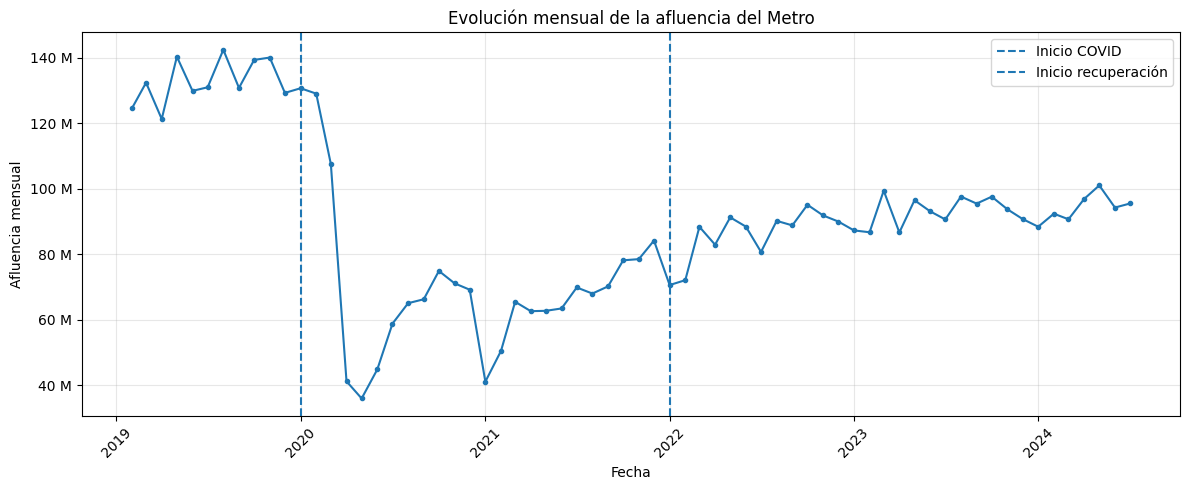

In [78]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    metro_comun["fecha_mes"],
    metro_comun["afluencia_metro"],
    marker="o",
    markersize=3
)

ax.axvline(
    pd.Timestamp("2020-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio COVID"
)

ax.axvline(
    pd.Timestamp("2022-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio recuperación"
)

ax.set_title("Evolución mensual de la afluencia del Metro")
ax.set_xlabel("Fecha")
ax.set_ylabel("Afluencia mensual")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f} M")
)

ax.grid(alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11.8 Evolución mensual de las carpetas de investigación

Se analiza la cantidad mensual de carpetas de investigación iniciadas en la Ciudad
de México. Este indicador representa registros de carpetas iniciadas y no debe
interpretarse directamente como la totalidad de delitos ocurridos.

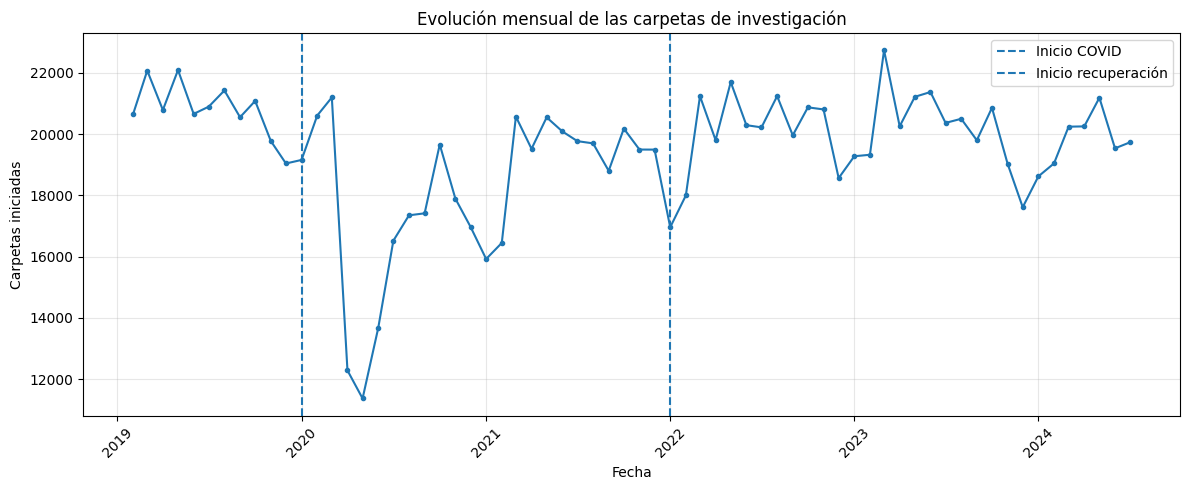

In [79]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    seguridad_comun["fecha_mes"],
    seguridad_comun["carpetas_fgJ"],
    marker="o",
    markersize=3
)

ax.axvline(
    pd.Timestamp("2020-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio COVID"
)

ax.axvline(
    pd.Timestamp("2022-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio recuperación"
)

ax.set_title("Evolución mensual de las carpetas de investigación")
ax.set_xlabel("Fecha")
ax.set_ylabel("Carpetas iniciadas")

ax.grid(alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11.9 Evolución mensual del empleo formal

El indicador económico representa la variación mensual en el número de empleos
formales registrados. Los valores positivos representan creación neta de puestos,
mientras que los valores negativos representan una pérdida neta.

La línea horizontal en cero permite identificar los meses en los que se registró
una reducción del empleo formal.

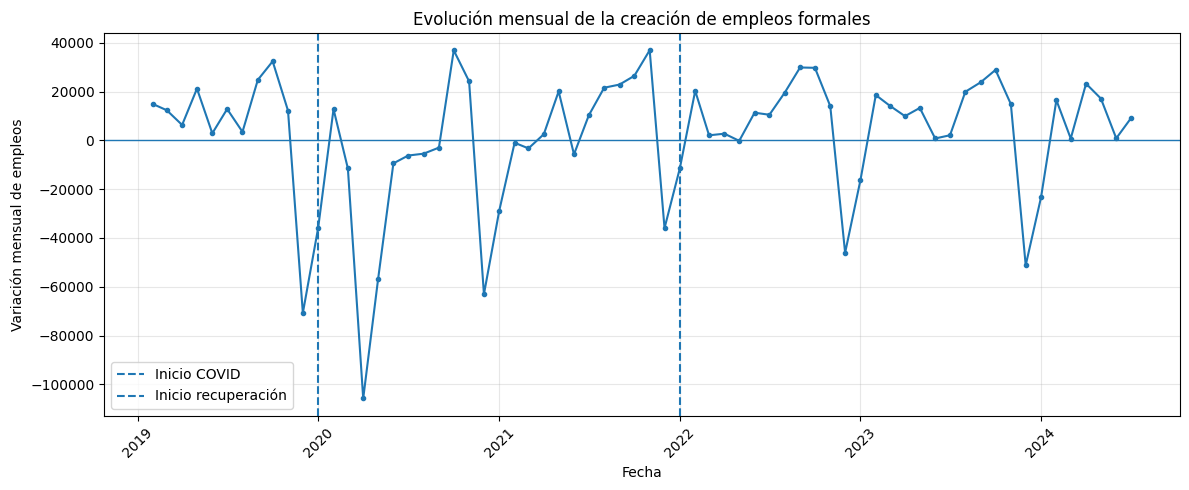

In [80]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    economia_comun["fecha_mes"],
    economia_comun["empleos_formales"],
    marker="o",
    markersize=3
)

ax.axhline(
    0,
    linestyle="-",
    linewidth=1
)

ax.axvline(
    pd.Timestamp("2020-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio COVID"
)

ax.axvline(
    pd.Timestamp("2022-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio recuperación"
)

ax.set_title("Evolución mensual de la creación de empleos formales")
ax.set_xlabel("Fecha")
ax.set_ylabel("Variación mensual de empleos")

ax.grid(alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11.10 Evolución mensual de la ocupación hotelera

Se representa el porcentaje mensual de ocupación hotelera en la Ciudad de México
para observar la caída de la actividad turística durante el periodo COVID y su
posterior recuperación.

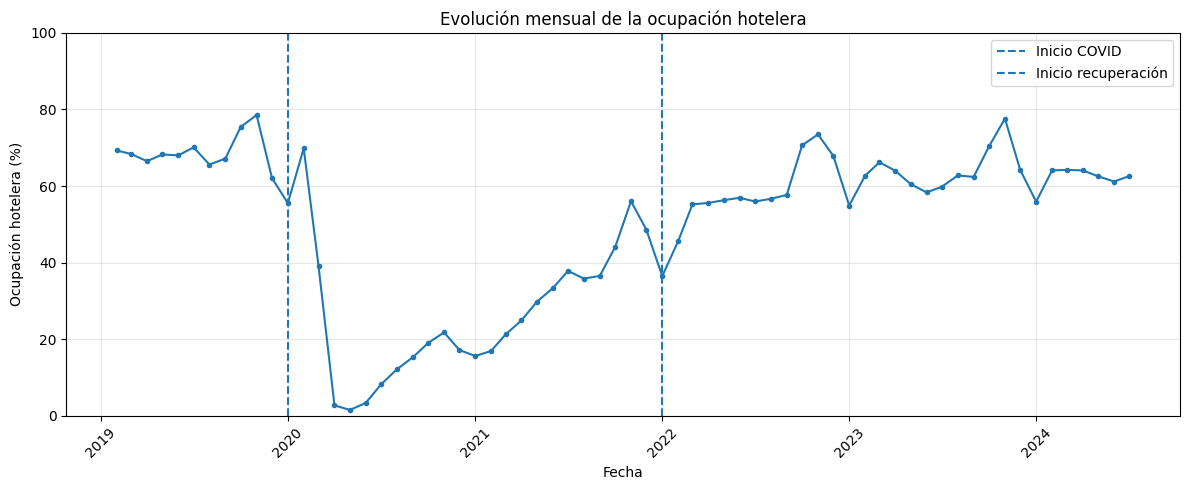

In [81]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    turismo_comun["fecha_mes"],
    turismo_comun["ocupacion_hotelera"],
    marker="o",
    markersize=3
)

ax.axvline(
    pd.Timestamp("2020-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio COVID"
)

ax.axvline(
    pd.Timestamp("2022-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Inicio recuperación"
)

ax.set_title("Evolución mensual de la ocupación hotelera")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ocupación hotelera (%)")

ax.set_ylim(0, 100)

ax.grid(alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11.11 Evolución de las hospitalizaciones por COVID-19

Las hospitalizaciones mensuales en la Ciudad de México se utilizan como indicador
de contexto epidemiológico.

Se emplean tanto el promedio mensual como el máximo mensual de personas
hospitalizadas para observar la intensidad de los diferentes periodos de la pandemia.

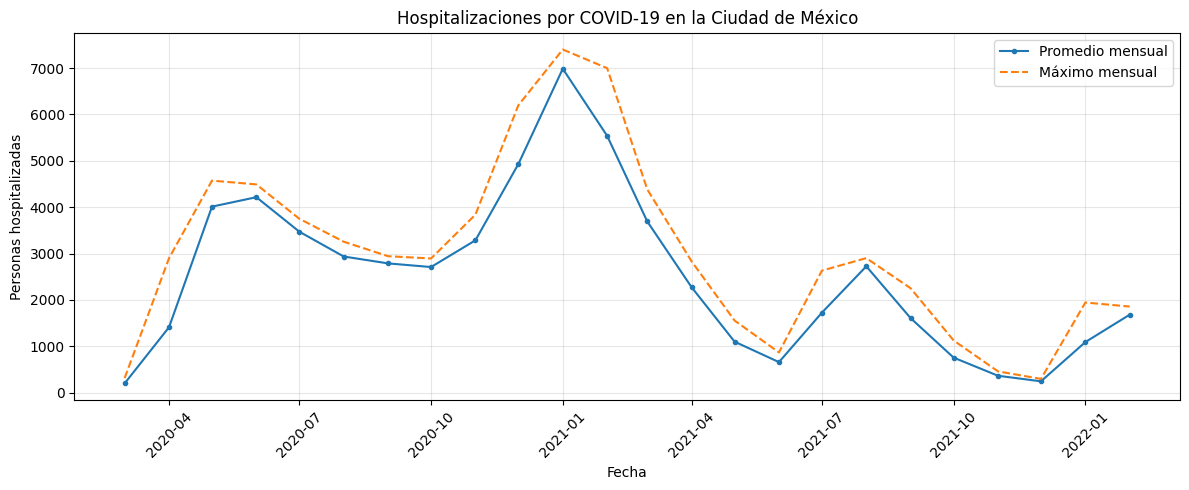

In [82]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    covid_mensual["fecha_mes"],
    covid_mensual["hospitalizados_promedio"],
    marker="o",
    markersize=3,
    label="Promedio mensual"
)

ax.plot(
    covid_mensual["fecha_mes"],
    covid_mensual["hospitalizados_maximo"],
    linestyle="--",
    label="Máximo mensual"
)

ax.set_title("Hospitalizaciones por COVID-19 en la Ciudad de México")
ax.set_xlabel("Fecha")
ax.set_ylabel("Personas hospitalizadas")

ax.grid(alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11.12 Comparación de indicadores normalizados y hospitalizaciones

Para comparar indicadores expresados en diferentes unidades se construyó un índice
tomando como referencia el promedio del periodo Pre-COVID.

Un valor de 100 representa el nivel promedio del indicador antes de la pandemia.
Valores inferiores a 100 representan niveles menores respecto a dicha referencia y
valores superiores a 100 representan niveles mayores.

Las hospitalizaciones por COVID-19 se presentan en un eje secundario únicamente como
contexto epidemiológico y no como evidencia de una relación causal directa.

In [83]:
# Medias de referencia Pre-COVID

media_pre_metro = metro_comun.loc[
    metro_comun["periodo"] == "Pre-COVID",
    "afluencia_metro"
].mean()

media_pre_seguridad = seguridad_comun.loc[
    seguridad_comun["periodo"] == "Pre-COVID",
    "carpetas_fgJ"
].mean()

media_pre_turismo = turismo_comun.loc[
    turismo_comun["periodo"] == "Pre-COVID",
    "ocupacion_hotelera"
].mean()


# Copias para no modificar las series originales

metro_indice = metro_comun.copy()
seguridad_indice = seguridad_comun.copy()
turismo_indice = turismo_comun.copy()


# Índices relativos

metro_indice["indice"] = (
    metro_indice["afluencia_metro"]
    / media_pre_metro
    * 100
)

seguridad_indice["indice"] = (
    seguridad_indice["carpetas_fgJ"]
    / media_pre_seguridad
    * 100
)

turismo_indice["indice"] = (
    turismo_indice["ocupacion_hotelera"]
    / media_pre_turismo
    * 100
)

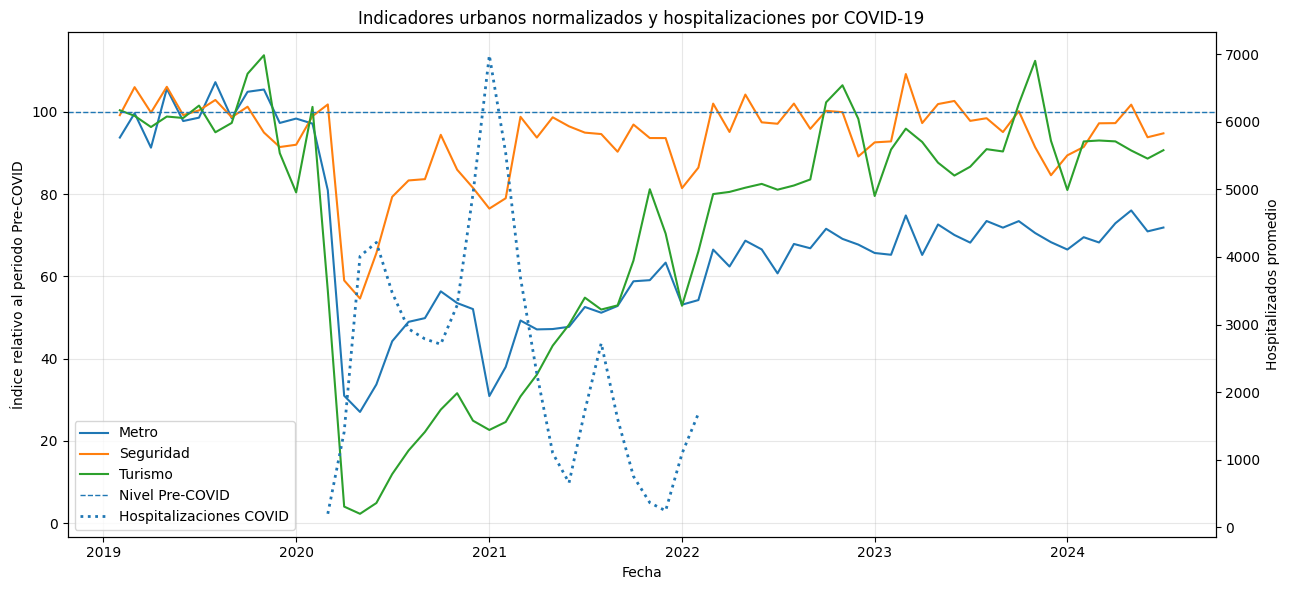

In [84]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(
    metro_indice["fecha_mes"],
    metro_indice["indice"],
    label="Metro"
)

ax1.plot(
    seguridad_indice["fecha_mes"],
    seguridad_indice["indice"],
    label="Seguridad"
)

ax1.plot(
    turismo_indice["fecha_mes"],
    turismo_indice["indice"],
    label="Turismo"
)

ax1.axhline(
    100,
    linestyle="--",
    linewidth=1,
    label="Nivel Pre-COVID"
)

ax1.set_xlabel("Fecha")
ax1.set_ylabel("Índice relativo al periodo Pre-COVID")
ax1.set_title(
    "Indicadores urbanos normalizados y hospitalizaciones por COVID-19"
)

ax1.grid(alpha=0.3)


# Segundo eje para hospitalizaciones

ax2 = ax1.twinx()

ax2.plot(
    covid_mensual["fecha_mes"],
    covid_mensual["hospitalizados_promedio"],
    linestyle=":",
    linewidth=2,
    label="Hospitalizaciones COVID"
)

ax2.set_ylabel("Hospitalizados promedio")


# Unimos las leyendas de ambos ejes

lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas_1 + lineas_2,
    etiquetas_1 + etiquetas_2,
    loc="best"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación de la comparación normalizada

La normalización de los indicadores permite observar que los distintos ámbitos
analizados presentaron comportamientos diferentes durante y después del periodo
COVID.

La movilidad en Metro y la actividad turística muestran las reducciones más
pronunciadas al inicio de la pandemia. La ocupación hotelera registra la caída
relativa más intensa, mientras que la afluencia del Metro también disminuye de
manera considerable.

Las carpetas de investigación presentan una reducción menor y posteriormente
regresan a valores cercanos a su nivel promedio Pre-COVID con mayor rapidez.

Durante el periodo de recuperación se observan diferencias importantes. El turismo
muestra una recuperación progresiva hasta aproximarse nuevamente a su referencia
Pre-COVID, mientras que la afluencia del Metro permanece por debajo de dicho nivel
durante todo el intervalo analizado.

Los periodos con mayores niveles de hospitalización por COVID-19 coinciden
temporalmente con algunas de las alteraciones más pronunciadas observadas en los
indicadores urbanos. Esta coincidencia se interpreta únicamente como una asociación
temporal y no como evidencia de causalidad.

## 11.13 Comparación interanual respecto a 2019

Debido a que algunos indicadores presentan estacionalidad, la comparación entre
periodos puede verse afectada por comportamientos propios de determinados meses.

Para reducir este efecto, cada observación de 2020 a 2024 se compara con el valor
registrado en el mismo mes de 2019, utilizado como año de referencia Pre-COVID.

Para movilidad, seguridad y turismo se calcula la variación porcentual respecto
al mismo mes de 2019.

En el caso del empleo formal se utiliza principalmente la diferencia absoluta,
debido a que el indicador puede tomar valores positivos y negativos, lo que dificulta
la interpretación de una variación porcentual.

In [85]:
def comparar_con_2019(df, columna):
    datos = df.copy()

    datos["anio"] = datos["fecha_mes"].dt.year
    datos["mes"] = datos["fecha_mes"].dt.month

    referencia = (
        datos[datos["anio"] == 2019]
        [["mes", columna]]
        .rename(columns={columna: "valor_2019"})
    )

    comparacion = datos.merge(
        referencia,
        on="mes",
        how="left"
    )

    comparacion["diferencia_vs_2019"] = (
        comparacion[columna]
        - comparacion["valor_2019"]
    )

    comparacion["variacion_pct_vs_2019"] = (
        comparacion["diferencia_vs_2019"]
        / comparacion["valor_2019"]
        * 100
    )

    return comparacion

In [86]:
metro_vs_2019 = comparar_con_2019(
    metro_comun,
    "afluencia_metro"
)

seguridad_vs_2019 = comparar_con_2019(
    seguridad_comun,
    "carpetas_fgJ"
)

economia_vs_2019 = comparar_con_2019(
    economia_comun,
    "empleos_formales"
)

turismo_vs_2019 = comparar_con_2019(
    turismo_comun,
    "ocupacion_hotelera"
)

print("Comparaciones contra 2019 generadas.")

Comparaciones contra 2019 generadas.


In [87]:
def resumen_anual_variacion(df, nombre):
    resultado = (
        df[df["anio"] >= 2020]
        .groupby("anio")
        .agg(
            diferencia_media=("diferencia_vs_2019", "mean"),
            variacion_media_pct=("variacion_pct_vs_2019", "mean")
        )
        .reset_index()
    )

    resultado.insert(0, "indicador", nombre)

    return resultado


resumen_metro_2019 = resumen_anual_variacion(
    metro_vs_2019,
    "Metro"
)

resumen_seguridad_2019 = resumen_anual_variacion(
    seguridad_vs_2019,
    "Seguridad"
)

resumen_turismo_2019 = resumen_anual_variacion(
    turismo_vs_2019,
    "Turismo"
)

display(resumen_metro_2019)
display(resumen_seguridad_2019)
display(resumen_turismo_2019)

,indicador,anio,diferencia_media,variacion_media_pct
0,Metro,2020,"-63,463,257.36",-47.47
1,Metro,2021,"-64,395,026.64",-48.48
2,Metro,2022,"-45,642,415.91",-34.35
3,Metro,2023,"-39,416,189.36",-29.62
4,Metro,2024,"-34,815,825.67",-26.68


,indicador,anio,diferencia_media,variacion_media_pct
0,Seguridad,2020,"-4,009.45",-19.07
1,Seguridad,2021,"-1,311.36",-6.21
2,Seguridad,2022,-576.64,-2.74
3,Seguridad,2023,-541.91,-2.67
4,Seguridad,2024,"-1,194.67",-5.63


,indicador,anio,diferencia_media,variacion_media_pct
0,Turismo,2020,-49.92,-72.46
1,Turismo,2021,-34.02,-49.39
2,Turismo,2022,-9.76,-14.09
3,Turismo,2023,-4.59,-6.61
4,Turismo,2024,-5.30,-7.72


In [88]:
resumen_empleo_2019 = (
    economia_vs_2019[
        economia_vs_2019["anio"] >= 2020
    ]
    .groupby("anio")
    .agg(
        diferencia_media_empleos=(
            "diferencia_vs_2019",
            "mean"
        )
    )
    .reset_index()
)

display(resumen_empleo_2019)

,anio,diferencia_media_empleos
0,2020,"-23,647.55"
1,2021,"2,013.00"
2,2022,"1,933.27"
3,2023,"2,052.91"
4,2024,-478.33


### Interpretación de la comparación interanual

La comparación con el mismo mes de 2019 permite reducir el efecto de la estacionalidad
presente en los indicadores y distinguir con mayor claridad los cambios observados
durante y después del periodo COVID.

La afluencia del Metro presenta una reducción persistente. Durante 2020 y 2021 se
mantiene aproximadamente 47 % y 48 % por debajo, respectivamente, de los valores
registrados en los mismos meses de 2019. Aunque posteriormente muestra una recuperación
progresiva, durante 2024 todavía permanece alrededor de 27 % por debajo de la referencia.

Las carpetas de investigación presentan una reducción considerable durante 2020,
de aproximadamente 19 %, pero posteriormente se aproximan con mayor rapidez a sus
niveles de 2019. Desde 2022 las diferencias se mantienen cercanas al nivel de referencia.

El turismo registra la mayor alteración de los ámbitos analizados. Durante 2020 la
ocupación hotelera se encuentra aproximadamente 72 % por debajo de los mismos meses
de 2019 y en 2021 todavía presenta una reducción cercana al 49 %. A partir de 2022
se observa una recuperación progresiva, con diferencias mucho menores respecto al
periodo previo.

En materia de empleo formal, durante 2020 se registró una diferencia promedio de
aproximadamente 23,648 empleos menos por mes respecto al mismo mes de 2019. A partir
de 2021, la diferencia promedio vuelve a ser positiva, mostrando una recuperación
más rápida que la observada en movilidad y turismo.

En conjunto, los resultados muestran que los ámbitos analizados no presentaron la
misma magnitud de afectación ni el mismo ritmo de recuperación posterior.

> **Nota:** Los resultados correspondientes a 2024 representan únicamente los meses
> disponibles dentro del periodo común de análisis y, por lo tanto, no deben
> interpretarse como resultados del año completo.

## 11.14 Asociación entre hospitalizaciones y los indicadores urbanos

Para explorar la relación temporal entre la intensidad de la pandemia y los
indicadores urbanos, se integraron los meses para los que existe información de
hospitalizaciones por COVID-19.

Se calculan los coeficientes de correlación de Pearson y Spearman.

- **Pearson** permite identificar asociaciones lineales.
- **Spearman** permite identificar asociaciones monotónicas y es menos sensible a
  valores extremos.

Los resultados se interpretan únicamente como asociaciones estadísticas y no como
evidencia de causalidad.

In [89]:
# Integración de las series durante el periodo con datos epidemiológicos

correlacion_df = (
    covid_mensual
    .merge(
        metro_mensual,
        on="fecha_mes",
        how="inner"
    )
    .merge(
        seguridad_mensual,
        on="fecha_mes",
        how="inner"
    )
    .merge(
        economia_mensual,
        on="fecha_mes",
        how="inner"
    )
    .merge(
        turismo_mensual,
        on="fecha_mes",
        how="inner"
    )
)

print("Meses utilizados:", len(correlacion_df))

print(
    "Periodo:",
    correlacion_df["fecha_mes"].min(),
    "→",
    correlacion_df["fecha_mes"].max()
)

display(correlacion_df.head())

Meses utilizados: 24
Periodo: 2020-03-01 00:00:00 → 2022-02-01 00:00:00


,fecha_mes,hospitalizados_promedio,hospitalizados_maximo,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera
0,2020-03-01,198.38,313,107531899,21200,-11503,39.02
1,2020-04-01,"1,410.20",2900,41139457,12288,-105804,2.76
2,2020-05-01,"4,011.65",4573,35899769,11372,-57004,1.55
3,2020-06-01,"4,215.17",4491,44780955,13672,-9428,3.36
4,2020-07-01,"3,471.06",3750,58756521,16523,-6217,8.22


In [90]:
variables_correlacion = [
    "hospitalizados_promedio",
    "afluencia_metro",
    "carpetas_fgJ",
    "empleos_formales",
    "ocupacion_hotelera"
]

correlacion_pearson = (
    correlacion_df[variables_correlacion]
    .corr(method="pearson")
)

correlacion_spearman = (
    correlacion_df[variables_correlacion]
    .corr(method="spearman")
)

print("=== CORRELACIÓN DE PEARSON ===")
display(correlacion_pearson)

print("\n=== CORRELACIÓN DE SPEARMAN ===")
display(correlacion_spearman)

=== CORRELACIÓN DE PEARSON ===


,hospitalizados_promedio,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera
hospitalizados_promedio,1.00,-0.63,-0.49,-0.23,-0.68
afluencia_metro,-0.63,1.00,0.78,0.45,0.74
carpetas_fgJ,-0.49,0.78,1.00,0.67,0.73
empleos_formales,-0.23,0.45,0.67,1.00,0.53
ocupacion_hotelera,-0.68,0.74,0.73,0.53,1.00



=== CORRELACIÓN DE SPEARMAN ===


,hospitalizados_promedio,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera
hospitalizados_promedio,1.00,-0.63,-0.56,-0.20,-0.73
afluencia_metro,-0.63,1.00,0.58,0.44,0.81
carpetas_fgJ,-0.56,0.58,1.00,0.50,0.67
empleos_formales,-0.20,0.44,0.50,1.00,0.47
ocupacion_hotelera,-0.73,0.81,0.67,0.47,1.00


In [91]:
resumen_correlaciones = pd.DataFrame({
    "Indicador": [
        "Afluencia del Metro",
        "Carpetas de investigación",
        "Empleos formales",
        "Ocupación hotelera"
    ],

    "Pearson_con_hospitalizaciones": [
        correlacion_pearson.loc[
            "hospitalizados_promedio",
            "afluencia_metro"
        ],
        correlacion_pearson.loc[
            "hospitalizados_promedio",
            "carpetas_fgJ"
        ],
        correlacion_pearson.loc[
            "hospitalizados_promedio",
            "empleos_formales"
        ],
        correlacion_pearson.loc[
            "hospitalizados_promedio",
            "ocupacion_hotelera"
        ]
    ],

    "Spearman_con_hospitalizaciones": [
        correlacion_spearman.loc[
            "hospitalizados_promedio",
            "afluencia_metro"
        ],
        correlacion_spearman.loc[
            "hospitalizados_promedio",
            "carpetas_fgJ"
        ],
        correlacion_spearman.loc[
            "hospitalizados_promedio",
            "empleos_formales"
        ],
        correlacion_spearman.loc[
            "hospitalizados_promedio",
            "ocupacion_hotelera"
        ]
    ]
})

resumen_correlaciones = resumen_correlaciones.round(3)

display(resumen_correlaciones)

,Indicador,Pearson_con_hospitalizaciones,Spearman_con_hospitalizaciones
0,Afluencia del Metro,-0.64,-0.63
1,Carpetas de investigación,-0.49,-0.56
2,Empleos formales,-0.23,-0.20
3,Ocupación hotelera,-0.68,-0.73


### Interpretación de las correlaciones

Durante los meses para los que existe información epidemiológica, las
hospitalizaciones por COVID-19 presentan asociaciones negativas con todos los
indicadores urbanos analizados.

La relación más intensa se observa en la ocupación hotelera, con coeficientes de
Pearson de -0.68 y Spearman de -0.73. Esto indica que los meses con mayores niveles
de hospitalización tendieron a coincidir con menores niveles de ocupación hotelera.

La afluencia del Metro también presenta una asociación negativa considerable, con
coeficientes de -0.64 en Pearson y -0.63 en Spearman, lo que muestra una tendencia
a menores niveles de movilidad durante meses con mayor hospitalización.

Las carpetas de investigación presentan una asociación negativa moderada
(Pearson = -0.49; Spearman = -0.56).

Por su parte, el empleo formal presenta una asociación negativa considerablemente
menor (Pearson = -0.23; Spearman = -0.20). Este resultado es consistente con la
alta variabilidad y estacionalidad observada en dicho indicador.

Estas correlaciones representan asociaciones temporales y no permiten establecer
relaciones causales entre la intensidad de la pandemia y el comportamiento de los
indicadores.

# 12. Construcción del dataset procesado para aprendizaje

Para conservar una cantidad suficiente de observaciones y mantener información
relevante sobre movilidad, se establece como unidad de observación la combinación:

**estación del Metro – línea – mes**

Cada registro representa el comportamiento mensual de una estación del Metro.

A esta información se incorporan indicadores contextuales mensuales de seguridad,
economía, turismo y, cuando se encuentran disponibles, hospitalizaciones por
COVID-19.

Esta estructura permite conservar la dimensión temporal y espacial de la movilidad
y genera un número de observaciones suficiente para aplicar posteriormente técnicas
de aprendizaje automático o minería de datos.

## 12.1 Afluencia mensual por estación

In [92]:
metro_estacion_mensual = (
    metro_limpio
    .assign(
        fecha_mes=metro_limpio["fecha"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby(
        ["fecha_mes", "linea", "estacion"],
        as_index=False
    )
    .agg(
        afluencia_estacion=("afluencia", "sum"),
        promedio_diario_estacion=("afluencia", "mean"),
        desviacion_diaria_estacion=("afluencia", "std")
    )
)

# Periodo común
metro_estacion_mensual = metro_estacion_mensual[
    metro_estacion_mensual["fecha_mes"].between(
        inicio_comun,
        fin_comun
    )
].copy()

print(
    "Registros estación-línea-mes:",
    f"{len(metro_estacion_mensual):,}"
)

print(
    "Combinaciones estación-línea:",
    metro_estacion_mensual[
        ["linea", "estacion"]
    ].drop_duplicates().shape[0]
)

display(metro_estacion_mensual.head())

Registros estación-línea-mes: 12,869
Combinaciones estación-línea: 197


,fecha_mes,linea,estacion,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion
2535,2019-02-01,Línea 1,Balbuena,367338,"13,119.21","2,489.76"
2536,2019-02-01,Línea 1,Balderas,638686,"22,810.21","6,235.95"
2537,2019-02-01,Línea 1,Boulevard Puerto Aéreo,675875,"24,138.39","3,298.86"
2538,2019-02-01,Línea 1,Candelaria,648318,"23,154.21","8,730.93"
2539,2019-02-01,Línea 1,Chapultepec,1505029,"53,751.04","8,148.91"


## 12.2 Integración de los indicadores contextuales

In [112]:
dataset_aprendizaje = (
    metro_estacion_mensual

    .merge(
        metro_comun[
            ["fecha_mes", "afluencia_metro"]
        ],
        on="fecha_mes",
        how="left"
    )

    .merge(
        seguridad_comun[
            ["fecha_mes", "carpetas_fgJ"]
        ],
        on="fecha_mes",
        how="left"
    )

    .merge(
        economia_comun[
            ["fecha_mes", "empleos_formales"]
        ],
        on="fecha_mes",
        how="left"
    )

    .merge(
        turismo_comun[
            ["fecha_mes", "ocupacion_hotelera"]
        ],
        on="fecha_mes",
        how="left"
    )

    .merge(
        covid_mensual,
        on="fecha_mes",
        how="left"
    )
)

print(
    "Dimensiones después de integrar:",
    dataset_aprendizaje.shape
)

display(dataset_aprendizaje.head())

Dimensiones después de integrar: (12868, 12)


,fecha_mes,linea,estacion,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera,hospitalizados_promedio,hospitalizados_maximo
0,2019-02-01,Línea 1,Balbuena,367338,"13,119.21","2,489.76",124568306,20659,14884,69.30,NaN,NaN
1,2019-02-01,Línea 1,Balderas,638686,"22,810.21","6,235.95",124568306,20659,14884,69.30,NaN,NaN
2,2019-02-01,Línea 1,Boulevard Puerto Aéreo,675875,"24,138.39","3,298.86",124568306,20659,14884,69.30,NaN,NaN
3,2019-02-01,Línea 1,Candelaria,648318,"23,154.21","8,730.93",124568306,20659,14884,69.30,NaN,NaN
4,2019-02-01,Línea 1,Chapultepec,1505029,"53,751.04","8,148.91",124568306,20659,14884,69.30,NaN,NaN


## 12.3 Variables derivadas

In [113]:
dataset_aprendizaje["anio"] = (
    dataset_aprendizaje["fecha_mes"].dt.year
)

dataset_aprendizaje["mes"] = (
    dataset_aprendizaje["fecha_mes"].dt.month
)

dataset_aprendizaje["periodo"] = (
    dataset_aprendizaje["fecha_mes"]
    .apply(periodo_mensual)
)

# Participación de cada estación en la afluencia total del sistema
dataset_aprendizaje["participacion_estacion_pct"] = (
    dataset_aprendizaje["afluencia_estacion"]
    / dataset_aprendizaje["afluencia_metro"]
    * 100
)

print("Variables derivadas creadas.")

display(
    dataset_aprendizaje.head()
)

Variables derivadas creadas.


,fecha_mes,linea,estacion,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera,hospitalizados_promedio,hospitalizados_maximo,anio,mes,periodo,participacion_estacion_pct
0,2019-02-01,Línea 1,Balbuena,367338,"13,119.21","2,489.76",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.29
1,2019-02-01,Línea 1,Balderas,638686,"22,810.21","6,235.95",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.51
2,2019-02-01,Línea 1,Boulevard Puerto Aéreo,675875,"24,138.39","3,298.86",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.54
3,2019-02-01,Línea 1,Candelaria,648318,"23,154.21","8,730.93",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.52
4,2019-02-01,Línea 1,Chapultepec,1505029,"53,751.04","8,148.91",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,1.21


In [114]:
print("=== DATASET INTEGRADO ===")

print(
    f"Registros: {len(dataset_aprendizaje):,}"
)

print(
    f"Columnas: {dataset_aprendizaje.shape[1]}"
)

print("\nValores faltantes:")
print(
    dataset_aprendizaje.isna().sum()
)

print("\nPeriodo:")
print(
    dataset_aprendizaje["fecha_mes"].min(),
    "→",
    dataset_aprendizaje["fecha_mes"].max()
)

print("\nPrimeros registros:")
display(dataset_aprendizaje.head())

=== DATASET INTEGRADO ===
Registros: 12,868
Columnas: 16

Valores faltantes:
fecha_mes                        0
linea                            0
estacion                         0
afluencia_estacion               0
promedio_diario_estacion         0
desviacion_diaria_estacion       0
afluencia_metro                  0
carpetas_fgJ                     0
empleos_formales                 0
ocupacion_hotelera               0
hospitalizados_promedio       8190
hospitalizados_maximo         8190
anio                             0
mes                              0
periodo                          0
participacion_estacion_pct       0
dtype: int64

Periodo:
2019-02-01 00:00:00 → 2024-07-01 00:00:00

Primeros registros:


,fecha_mes,linea,estacion,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera,hospitalizados_promedio,hospitalizados_maximo,anio,mes,periodo,participacion_estacion_pct
0,2019-02-01,Línea 1,Balbuena,367338,"13,119.21","2,489.76",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.29
1,2019-02-01,Línea 1,Balderas,638686,"22,810.21","6,235.95",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.51
2,2019-02-01,Línea 1,Boulevard Puerto Aéreo,675875,"24,138.39","3,298.86",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.54
3,2019-02-01,Línea 1,Candelaria,648318,"23,154.21","8,730.93",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,0.52
4,2019-02-01,Línea 1,Chapultepec,1505029,"53,751.04","8,148.91",124568306,20659,14884,69.30,NaN,NaN,2019,2,Pre-COVID,1.21


## 12.4 Preparación del dataset final para aprendizaje

Las variables de hospitalización por COVID-19 presentan valores faltantes fuera del
periodo en el que existe información epidemiológica.

Estos valores no se sustituyen por cero, debido a que la ausencia de información no
equivale a la existencia de cero personas hospitalizadas.

Por esta razón, las variables epidemiológicas se conservan para el análisis
contextual realizado previamente, pero no se incluyen como características del
dataset principal destinado a aprendizaje.

El dataset final conserva información mensual por estación y línea del Metro,
acompañada de indicadores de movilidad, seguridad, economía y turismo.

In [115]:
columnas_dataset_final = [
    "fecha_mes",
    "linea",
    "estacion",
    "afluencia_estacion",
    "promedio_diario_estacion",
    "desviacion_diaria_estacion",
    "afluencia_metro",
    "carpetas_fgJ",
    "empleos_formales",
    "ocupacion_hotelera",
    "anio",
    "mes",
    "periodo",
    "participacion_estacion_pct"
]

dataset_final = dataset_aprendizaje[
    columnas_dataset_final
].copy()

print("=== DATASET FINAL ===")
print(f"Registros: {len(dataset_final):,}")
print(f"Columnas: {dataset_final.shape[1]}")
print(f"Valores faltantes: {dataset_final.isna().sum().sum()}")

display(dataset_final.head())

=== DATASET FINAL ===
Registros: 12,868
Columnas: 14
Valores faltantes: 0


,fecha_mes,linea,estacion,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera,anio,mes,periodo,participacion_estacion_pct
0,2019-02-01,Línea 1,Balbuena,367338,"13,119.21","2,489.76",124568306,20659,14884,69.30,2019,2,Pre-COVID,0.29
1,2019-02-01,Línea 1,Balderas,638686,"22,810.21","6,235.95",124568306,20659,14884,69.30,2019,2,Pre-COVID,0.51
2,2019-02-01,Línea 1,Boulevard Puerto Aéreo,675875,"24,138.39","3,298.86",124568306,20659,14884,69.30,2019,2,Pre-COVID,0.54
3,2019-02-01,Línea 1,Candelaria,648318,"23,154.21","8,730.93",124568306,20659,14884,69.30,2019,2,Pre-COVID,0.52
4,2019-02-01,Línea 1,Chapultepec,1505029,"53,751.04","8,148.91",124568306,20659,14884,69.30,2019,2,Pre-COVID,1.21


## 12.5 Validación de la cobertura de estaciones

Antes de exportar el dataset se verifica que las combinaciones de estación, línea y
mes sean consistentes durante todo el periodo analizado.

Esta validación permite detectar meses en los que alguna estación no cuente con
registro disponible.

In [116]:
conteo_por_mes = (
    dataset_final
    .groupby("fecha_mes")
    .size()
    .reset_index(name="registros")
)

print("Número mínimo de estaciones-línea en un mes:")
print(conteo_por_mes["registros"].min())

print("\nNúmero máximo de estaciones-línea en un mes:")
print(conteo_por_mes["registros"].max())

print("\nMeses que no tienen el número máximo de registros:")
display(
    conteo_por_mes[
        conteo_por_mes["registros"]
        < conteo_por_mes["registros"].max()
    ]
)

Número mínimo de estaciones-línea en un mes:
193

Número máximo de estaciones-línea en un mes:
195

Meses que no tienen el número máximo de registros:


,fecha_mes,registros
22,2020-12-01,193


In [117]:
# Conjunto esperado de combinaciones línea-estación
combinaciones_esperadas = (
    dataset_final[
        dataset_final["fecha_mes"] != pd.Timestamp("2020-12-01")
    ][["linea", "estacion"]]
    .drop_duplicates()
)

# Combinaciones presentes en diciembre de 2020
combinaciones_dic2020 = (
    dataset_final[
        dataset_final["fecha_mes"] == pd.Timestamp("2020-12-01")
    ][["linea", "estacion"]]
    .drop_duplicates()
)

faltantes_dic2020 = (
    combinaciones_esperadas
    .merge(
        combinaciones_dic2020,
        on=["linea", "estacion"],
        how="left",
        indicator=True
    )
)

faltantes_dic2020 = faltantes_dic2020[
    faltantes_dic2020["_merge"] == "left_only"
][["linea", "estacion"]]

display(faltantes_dic2020)

,linea,estacion
177,Línea B,Deportivo Oceanía
186,Línea B,Oceanía


In [104]:
patron_estaciones = r"Gómez|Farias|Farías|Peñón|viejo|Viejo|Oceanía"

variantes_estaciones = (
    metro_limpio[
        metro_limpio["estacion"].str.contains(
            patron_estaciones,
            case=False,
            na=False,
            regex=True
        )
    ]
    [["linea", "estacion"]]
    .value_counts()
    .reset_index(name="registros")
)

display(variantes_estaciones)

,linea,estacion,registros
0,Línea B,Oceanía,2588
1,Línea 5,Valle Gómez,2557
2,Línea 5,Oceanía,2557
3,Línea B,Deportivo Oceanía,2526
4,Línea A,Peñón Viejo,1977
5,Línea 1,Gómez Farías,1977
6,Línea 1,Gómez Farias,580
7,Línea A,Peñón viejo,580


In [105]:
revision_dic2020 = metro_limpio[
    (metro_limpio["fecha"].dt.year == 2020) &
    (metro_limpio["fecha"].dt.month == 12) &
    (
        metro_limpio["estacion"].str.contains(
            patron_estaciones,
            case=False,
            na=False,
            regex=True
        )
    )
].copy()

display(
    revision_dic2020[
        ["fecha", "linea", "estacion", "afluencia"]
    ].sort_values(
        ["linea", "estacion", "fecha"]
    )
)

,fecha,linea,estacion,afluencia
207677,2020-12-01,Línea 1,Gómez Farías,22400
207872,2020-12-02,Línea 1,Gómez Farías,23905
208067,2020-12-03,Línea 1,Gómez Farías,25392
208262,2020-12-04,Línea 1,Gómez Farías,24153
208457,2020-12-05,Línea 1,Gómez Farías,21651
...,...,...,...,...
213299,2020-12-29,Línea B,Oceanía,5954
213493,2020-12-30,Línea B,Oceanía,5597
213494,2020-12-30,Línea B,Oceanía,6343
213688,2020-12-31,Línea B,Oceanía,4549


### Corrección de inconsistencias en nombres de estaciones

Durante la validación se identificaron variantes de escritura para las estaciones
`Gómez Farías` y `Peñón Viejo`.

Los registros correspondientes representan las mismas estaciones y únicamente
presentan diferencias de acentuación o uso de mayúsculas, por lo que se normalizan
sus nombres antes de realizar la agregación mensual.

También se detectó una anomalía en diciembre de 2020 para las estaciones `Oceanía`
y `Deportivo Oceanía` de la Línea B, la cual se analiza por separado antes de realizar
cualquier corrección.

In [106]:
metro_limpio["estacion"] = metro_limpio["estacion"].replace({
    "Gómez Farias": "Gómez Farías",
    "Peñón viejo": "Peñón Viejo"
})

print("Variantes de escritura corregidas.")

Variantes de escritura corregidas.


In [107]:
revision_oceania_dic2020 = (
    metro_limpio[
        (metro_limpio["fecha"].dt.year == 2020) &
        (metro_limpio["fecha"].dt.month == 12) &
        (metro_limpio["linea"] == "Línea B") &
        (metro_limpio["estacion"].isin([
            "Oceanía",
            "Deportivo Oceanía"
        ]))
    ]
    .sort_values(["fecha", "estacion"])
)

print("Registros encontrados:")
print(len(revision_oceania_dic2020))

print("\nConteo por estación:")
print(
    revision_oceania_dic2020["estacion"]
    .value_counts()
)

print("\nRegistros por día:")
display(
    revision_oceania_dic2020
    .groupby("fecha")
    .size()
    .reset_index(name="registros")
    .head(35)
)

Registros encontrados:
62

Conteo por estación:
estacion
Oceanía    62
Name: count, dtype: int64

Registros por día:


,fecha,registros
0,2020-12-01,2
1,2020-12-02,2
2,2020-12-03,2
3,2020-12-04,2
4,2020-12-05,2
5,2020-12-06,2
6,2020-12-07,2
7,2020-12-08,2
8,2020-12-09,2
9,2020-12-10,2


In [108]:
referencia_oceania = metro_limpio[
    (metro_limpio["linea"] == "Línea B") &
    (metro_limpio["estacion"].isin([
        "Oceanía",
        "Deportivo Oceanía"
    ])) &
    (
        (
            (metro_limpio["fecha"].dt.year == 2020) &
            (metro_limpio["fecha"].dt.month == 11)
        )
        |
        (
            (metro_limpio["fecha"].dt.year == 2021) &
            (metro_limpio["fecha"].dt.month == 1)
        )
    )
].copy()

resumen_referencia = (
    referencia_oceania
    .assign(
        periodo=referencia_oceania["fecha"].dt.to_period("M")
    )
    .groupby(["periodo", "estacion"])["afluencia"]
    .agg(
        registros="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .reset_index()
)

display(resumen_referencia)

,periodo,estacion,registros,media,mediana,minimo,maximo
0,2020-11,Deportivo Oceanía,30,"7,310.00","7,740.00",4743,9491
1,2020-11,Oceanía,30,"5,625.03","5,940.50",2735,7295
2,2021-01,Deportivo Oceanía,31,"5,809.32","6,414.00",2317,7920
3,2021-01,Oceanía,31,"5,521.45","5,111.00",1653,12685


In [109]:
pares_dic2020 = (
    revision_oceania_dic2020
    .groupby("fecha")["afluencia"]
    .agg(
        valor_menor="min",
        valor_mayor="max"
    )
    .reset_index()
)

display(pares_dic2020)

print("\nResumen de los dos valores diarios:")
display(
    pares_dic2020[
        ["valor_menor", "valor_mayor"]
    ].describe()
)

,fecha,valor_menor,valor_mayor
0,2020-12-01,5559,7529
1,2020-12-02,5198,9766
2,2020-12-03,5467,8446
3,2020-12-04,6158,8374
4,2020-12-05,6096,7815
5,2020-12-06,3731,5183
6,2020-12-07,5562,8159
7,2020-12-08,5861,7632
8,2020-12-09,5450,9169
9,2020-12-10,6870,7604



Resumen de los dos valores diarios:


,valor_menor,valor_mayor
count,31.00,31.00
mean,"5,222.13","7,139.03"
std,"1,187.91","1,766.72"
min,"2,426.00","2,431.00"
25%,"4,686.50","5,965.00"
50%,"5,562.00","7,604.00"
75%,"6,023.50","8,410.00"
max,"7,036.00","9,766.00"


### Tratamiento de la anomalía Oceanía – Deportivo Oceanía

Durante diciembre de 2020 se identificaron 62 registros de la Línea B etiquetados
como `Oceanía`, correspondientes a dos observaciones por día. En ese mismo mes no
existen registros con el nombre `Deportivo Oceanía`.

En los meses anterior y posterior ambas estaciones aparecen normalmente como
entidades independientes. Esto indica que durante diciembre de 2020 los registros
de ambas estaciones fueron almacenados bajo el mismo nombre.

Aunque los valores diarios presentan diferencias que podrían permitir una
clasificación aproximada, las distribuciones de ambas estaciones se superponen y
no existe información suficiente para determinar con certeza cuál observación
corresponde a cada estación.

Por esta razón, los registros ambiguos de diciembre de 2020 se excluyen únicamente
del análisis a nivel estación. La afluencia total del Metro no se modifica, debido
a que los valores originales continúan siendo válidos para las agregaciones globales.

In [110]:
# Normalización de nombres inequívocos
metro_limpio["estacion"] = metro_limpio["estacion"].replace({
    "Gómez Farias": "Gómez Farías",
    "Peñón viejo": "Peñón Viejo"
})

# Identificación de los registros ambiguos de diciembre de 2020
mascara_oceania_ambigua = (
    (metro_limpio["fecha"].dt.year == 2020) &
    (metro_limpio["fecha"].dt.month == 12) &
    (metro_limpio["linea"] == "Línea B") &
    (metro_limpio["estacion"] == "Oceanía")
)

print(
    "Registros ambiguos identificados:",
    mascara_oceania_ambigua.sum()
)

# Dataset específico para análisis por estación
metro_estaciones_limpio = metro_limpio[
    ~mascara_oceania_ambigua
].copy()

print(
    "Registros disponibles para análisis por estación:",
    f"{len(metro_estaciones_limpio):,}"
)

Registros ambiguos identificados: 62
Registros disponibles para análisis por estación: 498,553


In [111]:
metro_estacion_mensual = (
    metro_estaciones_limpio
    .assign(
        fecha_mes=metro_estaciones_limpio["fecha"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby(
        ["fecha_mes", "linea", "estacion"],
        as_index=False
    )
    .agg(
        afluencia_estacion=("afluencia", "sum"),
        promedio_diario_estacion=("afluencia", "mean"),
        desviacion_diaria_estacion=("afluencia", "std")
    )
)

metro_estacion_mensual = metro_estacion_mensual[
    metro_estacion_mensual["fecha_mes"].between(
        inicio_comun,
        fin_comun
    )
].copy()

print(
    "Registros estación-línea-mes:",
    f"{len(metro_estacion_mensual):,}"
)

print(
    "Combinaciones estación-línea:",
    metro_estacion_mensual[
        ["linea", "estacion"]
    ].drop_duplicates().shape[0]
)

Registros estación-línea-mes: 12,868
Combinaciones estación-línea: 195


## 12.6 Selección de características para aprendizaje

Para la preparación del dataset destinado a técnicas posteriores de minería de datos,
se distinguen las variables identificadoras de las variables utilizadas como
características.

Las variables `linea` y `estacion` se conservan para identificar e interpretar cada
observación, pero la estación no se codifica mediante variables binarias debido a
que representa una identidad y no una característica numérica de comportamiento.

Las características destinadas al aprendizaje se seleccionan principalmente a partir
del comportamiento de afluencia de cada estación y de los indicadores contextuales
de la ciudad.

In [118]:
# Variables que conservamos para identificar posteriormente cada resultado
identificadores = dataset_final[
    ["fecha_mes", "linea", "estacion", "periodo"]
].copy()

# Variables numéricas potencialmente utilizables por algoritmos posteriores
columnas_modelo = [
    "afluencia_estacion",
    "promedio_diario_estacion",
    "desviacion_diaria_estacion",
    "afluencia_metro",
    "carpetas_fgJ",
    "empleos_formales",
    "ocupacion_hotelera",
    "anio",
    "mes",
    "participacion_estacion_pct"
]

dataset_modelo = dataset_final[
    columnas_modelo
].copy()

print("=== DATASET NUMÉRICO PARA APRENDIZAJE ===")
print(f"Registros: {dataset_modelo.shape[0]:,}")
print(f"Características: {dataset_modelo.shape[1]}")
print(f"Nulos: {dataset_modelo.isna().sum().sum()}")

display(dataset_modelo.head())

=== DATASET NUMÉRICO PARA APRENDIZAJE ===
Registros: 12,868
Características: 10
Nulos: 0


,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera,anio,mes,participacion_estacion_pct
0,367338,"13,119.21","2,489.76",124568306,20659,14884,69.30,2019,2,0.29
1,638686,"22,810.21","6,235.95",124568306,20659,14884,69.30,2019,2,0.51
2,675875,"24,138.39","3,298.86",124568306,20659,14884,69.30,2019,2,0.54
3,648318,"23,154.21","8,730.93",124568306,20659,14884,69.30,2019,2,0.52
4,1505029,"53,751.04","8,148.91",124568306,20659,14884,69.30,2019,2,1.21


## 12.7 Validación final del dataset procesado

Después de la limpieza, integración y selección de características, el dataset
destinado a etapas posteriores de minería de datos contiene 12,868 observaciones
y 10 variables numéricas, sin valores faltantes.

La unidad de observación corresponde a una combinación estación-línea-mes.

Durante diciembre de 2020 se excluyeron del análisis por estación las observaciones
correspondientes a `Oceanía` y `Deportivo Oceanía` de la Línea B, debido a una
inconsistencia en el archivo original que impide distinguir con certeza cuál de las
dos observaciones diarias corresponde a cada estación.

Esta exclusión afecta únicamente el análisis a nivel estación y no modifica los
totales generales de afluencia del Metro utilizados en el análisis estadístico.

In [119]:
print("=== VALIDACIÓN FINAL ===")

print(f"Registros: {dataset_modelo.shape[0]:,}")
print(f"Características: {dataset_modelo.shape[1]}")
print(f"Valores faltantes: {dataset_modelo.isna().sum().sum()}")
print(f"Duplicados exactos: {dataset_modelo.duplicated().sum()}")

print("\nTipos de datos:")
display(dataset_modelo.dtypes.to_frame("tipo"))

=== VALIDACIÓN FINAL ===
Registros: 12,868
Características: 10
Valores faltantes: 0
Duplicados exactos: 751

Tipos de datos:


,tipo
afluencia_estacion,int64
promedio_diario_estacion,float64
desviacion_diaria_estacion,float64
afluencia_metro,int64
carpetas_fgJ,int64
empleos_formales,int64
ocupacion_hotelera,float64
anio,int32
mes,int32
participacion_estacion_pct,float64


# 13. Generación de archivos procesados

Se conserva una versión completa del dataset procesado con variables descriptivas
para facilitar su interpretación.

Asimismo, se genera una muestra aleatoria de 100 observaciones, utilizando una
semilla fija (`random_state=42`) para garantizar que la selección sea reproducible.

El muestreo se realiza sin reemplazo, por lo que cada registro seleccionado aparece
una sola vez como observación de la muestra.

## 13.1 Guardar dataset completo

In [120]:
dataset_final.to_csv(
    "dataset_procesado_completo.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Dataset completo guardado:",
    f"{len(dataset_final):,} registros"
)

Dataset completo guardado: 12,868 registros


## 13.2 Generar muestra aleatoria de 100 registros

In [121]:
muestra_100 = (
    dataset_final
    .sample(
        n=100,
        random_state=42
    )
    .reset_index(drop=True)
)

display(muestra_100.head(10))

,fecha_mes,linea,estacion,afluencia_estacion,promedio_diario_estacion,desviacion_diaria_estacion,afluencia_metro,carpetas_fgJ,empleos_formales,ocupacion_hotelera,anio,mes,periodo,participacion_estacion_pct
0,2023-11-01,Línea 2,Zócalo/Tenochtitlan,856655,"28,555.17","13,205.81",93718684,19035,14849,77.60,2023,11,Recuperación,0.91
1,2021-09-01,Línea 12,Zapata,0,0.00,0.00,70154247,18805,22864,36.54,2021,9,COVID,0.00
2,2019-02-01,Línea 1,Isabel la Católica,644610,"23,021.79","6,426.83",124568306,20659,14884,69.30,2019,2,Pre-COVID,0.52
3,2019-06-01,Línea 2,Tasqueña,2224255,"74,141.83","13,461.11",129909461,20662,2886,68.01,2019,6,Pre-COVID,1.71
4,2023-01-01,Línea 7,San Antonio,261764,"8,444.00","2,569.64",87266174,19280,-16288,54.91,2023,1,Recuperación,0.30
5,2022-06-01,Línea 1,Balbuena,269952,"8,998.40","1,645.56",88424030,20295,11338,56.94,2022,6,Recuperación,0.31
6,2020-09-01,Línea 5,Aragón,112060,"3,735.33",753.65,66219212,17417,-2980,15.30,2020,9,COVID,0.17
7,2021-01-01,Línea 3,La Raza,111577,"3,599.26","6,623.95",41033642,15926,-28769,15.63,2021,1,COVID,0.27
8,2021-08-01,Línea 1,Pantitlán,748274,"24,137.87","4,538.13",67964499,19701,21572,35.84,2021,8,COVID,1.10
9,2023-06-01,Línea 5,Terminal Aérea,475281,"15,842.70","2,765.17",93088935,21377,774,58.34,2023,6,Recuperación,0.51


## 13.3 Guardar muestra

In [122]:
muestra_100.to_csv(
    "dataset_procesado_muestra_100.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo generado: dataset_procesado_muestra_100.csv")
print("Registros:", len(muestra_100))
print("Valores faltantes:", muestra_100.isna().sum().sum())

Archivo generado: dataset_procesado_muestra_100.csv
Registros: 100
Valores faltantes: 0


In [123]:
dataset_modelo.to_csv(
    "dataset_modelo_numerico.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo generado: dataset_modelo_numerico.csv")

Archivo generado: dataset_modelo_numerico.csv
